In [1]:
import pandas as pd
import numpy as np
# ignore scorecardpy compatability warnings
import warnings

import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn import linear_model, metrics
import scorecardpy as sc
import pprint
new_merged_df = pd.read_csv('clean_data/final_merged_data.csv')

/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
new_merged_df.shape

(20104, 157)

In [3]:
#shinus columns
iteration1df = new_merged_df.copy()
iteration1df = iteration1df.drop(columns=['SK_ID_CURR'], axis = 1)
iteration1df = iteration1df.drop(columns=['CODE_GENDER'])
iteration1df = iteration1df.drop(columns=['FLAG_OWN_REALTY'])

In [4]:
#jewels columns, deleted those that have more than 50% data missing
iteration1df = iteration1df.drop(columns=['APARTMENTS_AVG'])
iteration1df = iteration1df.drop(columns=['BASEMENTAREA_AVG'])
iteration1df = iteration1df.drop(columns=['YEARS_BEGINEXPLUATATION_AVG'])
iteration1df = iteration1df.drop(columns=['YEARS_BUILD_AVG'])
iteration1df = iteration1df.drop(columns=['COMMONAREA_AVG'])
iteration1df = iteration1df.drop(columns=['ELEVATORS_AVG'])
iteration1df = iteration1df.drop(columns=['ENTRANCES_AVG'])
iteration1df = iteration1df.drop(columns=['FLOORSMAX_AVG'])
iteration1df = iteration1df.drop(columns=['FLOORSMIN_AVG'])
iteration1df = iteration1df.drop(columns=['LANDAREA_AVG'])


In [5]:
#roopas columns, deleted those that have more than 50% data missing
iteration1df = iteration1df.drop(columns=['LIVINGAPARTMENTS_AVG'])
iteration1df = iteration1df.drop(columns=['LIVINGAREA_AVG'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAPARTMENTS_AVG'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAREA_AVG'])
iteration1df = iteration1df.drop(columns=['APARTMENTS_MODE'])
iteration1df = iteration1df.drop(columns=['BASEMENTAREA_MODE'])
iteration1df = iteration1df.drop(columns=['YEARS_BEGINEXPLUATATION_MODE'])
iteration1df = iteration1df.drop(columns=['YEARS_BUILD_MODE'])
iteration1df = iteration1df.drop(columns=['COMMONAREA_MODE'])
iteration1df = iteration1df.drop(columns=['ELEVATORS_MODE'])
iteration1df = iteration1df.drop(columns=['ENTRANCES_MODE'])
iteration1df = iteration1df.drop(columns=['FLOORSMAX_MODE'])
iteration1df = iteration1df.drop(columns=['FLOORSMIN_MODE'])
iteration1df = iteration1df.drop(columns=['LANDAREA_MODE'])
iteration1df = iteration1df.drop(columns=['LIVINGAPARTMENTS_MODE'])
iteration1df = iteration1df.drop(columns=['LIVINGAREA_MODE'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAPARTMENTS_MODE'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAREA_MODE'])
iteration1df = iteration1df.drop(columns=['APARTMENTS_MEDI'])
iteration1df = iteration1df.drop(columns=['BASEMENTAREA_MEDI'])
iteration1df = iteration1df.drop(columns=['YEARS_BEGINEXPLUATATION_MEDI'])
iteration1df = iteration1df.drop(columns=['YEARS_BUILD_MEDI'])
iteration1df = iteration1df.drop(columns=['COMMONAREA_MEDI'])
iteration1df = iteration1df.drop(columns=['ELEVATORS_MEDI'])
iteration1df = iteration1df.drop(columns=['ENTRANCES_MEDI'])
iteration1df = iteration1df.drop(columns=['FLOORSMAX_MEDI'])
iteration1df = iteration1df.drop(columns=['FLOORSMIN_MEDI'])

In [6]:
#anshikas columns, more than 50% missing
iteration1df = iteration1df.drop(columns=[
    'NONLIVINGAPARTMENTS_MEDI',
    'FONDKAPREMONT_MODE',
    'LIVINGAPARTMENTS_MEDI',
    'LANDAREA_MEDI',
    'NONLIVINGAREA_MEDI',
    'WALLSMATERIAL_MODE',
    'LIVINGAREA_MEDI',
    'HOUSETYPE_MODE'
])

In [7]:
# Compute correlations and ignore categorical variables first and delete all the low value numerical variables 
corr = iteration1df.corr(method='pearson', numeric_only=True)

# Get correlation of all numeric features with TARGET
target_corr = corr['TARGET']

# Filter features with low correlation (-0.1 < corr < 0.3)
low_corr_features = target_corr[(target_corr >= -0.05) & (target_corr <= 0.05)].index.tolist()

print("Low correlation featureas with TARGET:")
print(low_corr_features)




Low correlation featureas with TARGET:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'OWN_CAR_AGE', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'LIVE_CITY_NOT_WORK_CITY', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CR

In [8]:
iteration1df = iteration1df.drop(columns=['CNT_CHILDREN'])
iteration1df = iteration1df.drop(columns=['AMT_INCOME_TOTAL'])
iteration1df = iteration1df.drop(columns=['AMT_CREDIT'])
iteration1df = iteration1df.drop(columns=['AMT_ANNUITY'])
iteration1df = iteration1df.drop(columns=['AMT_GOODS_PRICE'])
iteration1df = iteration1df.drop(columns=['REGION_POPULATION_RELATIVE'])
iteration1df = iteration1df.drop(columns=['DAYS_EMPLOYED'])
iteration1df = iteration1df.drop(columns=['DAYS_REGISTRATION'])
iteration1df = iteration1df.drop(columns=['OWN_CAR_AGE'])
iteration1df = iteration1df.drop(columns=['CNT_FAM_MEMBERS'])
iteration1df = iteration1df.drop(columns=['HOUR_APPR_PROCESS_START'])
iteration1df = iteration1df.drop(columns=['TOTALAREA_MODE'])
iteration1df = iteration1df.drop(columns=['OBS_30_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['DEF_30_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['OBS_60_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['DEF_60_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_HOUR'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_DAY'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_WEEK'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_MON'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_QRT'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_YEAR'])
iteration1df = iteration1df.drop(columns=['TOTAL_CREDIT_LIMIT'])
iteration1df = iteration1df.drop(columns=['SUM_CNT_CREDIT_PROLONG'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Another type of loan'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Car loan'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Consumer credit'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Credit card'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Loan for business development'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Loan for working capital replenishment'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Microloan'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Mortgage'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Real estate loan'])
iteration1df = iteration1df.drop(columns=['CREDIT_TYPE_Unknown type of loan'])
iteration1df = iteration1df.drop(columns=['MAX_RECENCY_CLOSED_LOAN'])
iteration1df = iteration1df.drop(columns=['MAX_OVERDUE_AMOUNT'])
iteration1df = iteration1df.drop(columns=['COUNT_OVERDUE_LOANS'])
iteration1df = iteration1df.drop(columns=['TOTAL_CLOSED'])
iteration1df = iteration1df.drop(columns=['TOTAL_SOLD'])
iteration1df = iteration1df.drop(columns=['COUNT_LOCAL_CURRENCY_LOANS'])
iteration1df = iteration1df.drop(columns=['COUNT_FOREIGN_CURRENCY_LOANS'])
iteration1df = iteration1df.drop(columns=['DAYS_CREDIT_RECENT'])
iteration1df = iteration1df.drop(columns=['AVERAGE_DAYS_OVERDUE'])
iteration1df = iteration1df.drop(columns=['TOTAL_ANNUITY'])





In [9]:
# check the actual correlation of the categorical variables
from scipy.stats import chi2_contingency
results = {}
categorical_vars = [
    'NAME_CONTRACT_TYPE',
    'FLAG_OWN_CAR',
    'NAME_TYPE_SUITE',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'FLAG_MOBIL',
    'FLAG_EMP_PHONE',
    'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'OCCUPATION_TYPE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',
    'WEEKDAY_APPR_PROCESS_START',
    'REG_REGION_NOT_LIVE_REGION',
    'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION',
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY',
    'ORGANIZATION_TYPE',
    'EMERGENCYSTATE_MODE',
    'FLAG_DOCUMENT_2',
    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8',
    'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_11',
    'FLAG_DOCUMENT_12',
    'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14',
    'FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20',
    'FLAG_DOCUMENT_21',
    'HAS_BUREAU_HISTORY'
]

# bureau_features = [
#     'MAX_AMT_CREDIT_SUM_OVERDUE',
#     'DEBT_RATIO',
#     'AVERAGE_CREDIT_DAY_OVERDUE',
#     'TOTAL_CREDIT_LIMIT',
#     'SUM_CNT_CREDIT_PROLONG',
#     'CREDIT_TYPE_Another type of loan',
#     'CREDIT_TYPE_Car loan',
#     'CREDIT_TYPE_Cash loan (non-earmarked)',
#     'CREDIT_TYPE_Consumer credit',
#     'CREDIT_TYPE_Credit card',
#     'CREDIT_TYPE_Interbank credit',
#     'CREDIT_TYPE_Loan for business development',
#     'CREDIT_TYPE_Loan for purchase of shares (margin lending)',
#     'CREDIT_TYPE_Loan for the purchase of equipment',
#     'CREDIT_TYPE_Loan for working capital replenishment',
#     'CREDIT_TYPE_Microloan',
#     'CREDIT_TYPE_Mobile operator loan',
#     'CREDIT_TYPE_Mortgage',
#     'CREDIT_TYPE_Real estate loan',
#     'CREDIT_TYPE_Unknown type of loan',
#     'MAX_RECENCY_CLOSED_LOAN',
#     'AVG_LOAN_DURATION_ACTUAL',
#     'MAX_OVERDUE_AMOUNT',
#     'COUNT_OVERDUE_LOANS',
#     'TOTAL_ACTIVE',
#     'TOTAL_CLOSED',
#     'TOTAL_SOLD',
#     'TOTAL_BAD_DEBT',
#     'COUNT_LOCAL_CURRENCY_LOANS',
#     'COUNT_FOREIGN_CURRENCY_LOANS',
#     'DAYS_CREDIT_RECENT',
#     'DAYS_CREDIT_OLDEST',
#     'RECENT_LOAN_COUNT',
#     'AVERAGE_DAYS_OVERDUE',
#     'AVERAGE_DAYS_CREDIT_UPDATE',
#     'TOTAL_ANNUITY'
# ]

for var in categorical_vars:
    table = pd.crosstab(iteration1df[var], iteration1df['TARGET'])
    chi2, p, dof, expected = chi2_contingency(table)
    results[var] = float(p)


In [10]:
# useless columns - comparing all categorical vars to the TARGET, any w lesser correlation we r dropping

useless = []
for variable in results:
    if(results[variable] > 0.5):
        useless.append(variable)

useless

['FLAG_MOBIL',
 'FLAG_EMAIL',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'EMERGENCYSTATE_MODE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20']

In [11]:
#drop useless columns
iteration1df = iteration1df.drop(columns=['FLAG_MOBIL',
 'FLAG_EMAIL',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'EMERGENCYSTATE_MODE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20'])

In [12]:
# # all numeric columns that were not dropped
# DAYS_BIRTH
# DAYS_ID_PUBLISH
# EXT_SOURCE_1
# DAYS_LAST_PHONE_CHANGE

iteration1df




,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_ID_PUBLISH,...,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Mobile operator loan,AVG_LOAN_DURATION_ACTUAL,TOTAL_ACTIVE,TOTAL_BAD_DEBT,DAYS_CREDIT_OLDEST,RECENT_LOAN_COUNT,AVERAGE_DAYS_CREDIT_UPDATE,HAS_BUREAU_HISTORY
0,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Married,Rented apartment,-11146,-2518,...,0.0,0.0,0.0,728.0,2.0,0.0,-1644.0,0.0,-314.666667,Yes
1,0,Cash loans,N,Family,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-21621,-1344,...,0.0,0.0,0.0,NaN,2.0,0.0,-509.0,0.0,-96.500000,Yes
2,0,Cash loans,N,Unaccompanied,Working,Incomplete higher,Single / not married,With parents,-7907,-586,...,0.0,0.0,0.0,346.0,0.0,0.0,-630.0,0.0,-214.500000,Yes
3,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,With parents,-10485,-3110,...,0.0,0.0,0.0,441.0,3.0,0.0,-2257.0,0.0,-474.916667,Yes
4,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10954,-596,...,0.0,0.0,0.0,NaN,3.0,0.0,-545.0,0.0,-32.666667,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10592,-2208,...,0.0,0.0,0.0,240.0,1.0,0.0,-1333.0,1.0,-475.500000,Yes
20100,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Single / not married,With parents,-8146,-813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20101,0,Cash loans,N,Unaccompanied,State servant,Higher education,Married,Rented apartment,-10567,-2188,...,0.0,0.0,0.0,239.0,2.0,0.0,-1594.0,0.0,-458.800000,Yes
20102,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,Rented apartment,-12847,-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [13]:
numeric_columns = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'REGION_POPULATION_RELATIVE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'OWN_CAR_AGE',
    'CNT_FAM_MEMBERS',
    'HOUR_APPR_PROCESS_START',
    'EXT_SOURCE_1',
    'APARTMENTS_AVG',
    'BASEMENTAREA_AVG',
    'YEARS_BEGINEXPLUATATION_AVG',
    'YEARS_BUILD_AVG',
    'COMMONAREA_AVG',
    'ELEVATORS_AVG',
    'ENTRANCES_AVG',
    'FLOORSMAX_AVG',
    'FLOORSMIN_AVG',
    'LANDAREA_AVG',
    'LIVINGAPARTMENTS_AVG',
    'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG',
    'NONLIVINGAREA_AVG',
    'APARTMENTS_MODE',
    'BASEMENTAREA_MODE',
    'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_MODE',
    'COMMONAREA_MODE',
    'ELEVATORS_MODE',
    'ENTRANCES_MODE',
    'FLOORSMAX_MODE',
    'FLOORSMIN_MODE',
    'LANDAREA_MODE',
    'LIVINGAPARTMENTS_MODE',
    'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAREA_MODE',
    'APARTMENTS_MEDI',
    'BASEMENTAREA_MEDI',
    'YEARS_BEGINEXPLUATATION_MEDI',
    'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI',
    'ELEVATORS_MEDI',
    'ENTRANCES_MEDI',
    'FLOORSMAX_MEDI',
    'FLOORSMIN_MEDI',
    'LANDAREA_MEDI',
    'LIVINGAPARTMENTS_MEDI',
    'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI',
    'NONLIVINGAREA_MEDI',
    'TOTALAREA_MODE',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE',
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'MAX_AMT_CREDIT_SUM_OVERDUE',
    'DEBT_RATIO',
    'AVERAGE_CREDIT_DAY_OVERDUE',
    'TOTAL_CREDIT_LIMIT',
    'SUM_CNT_CREDIT_PROLONG',
    'CREDIT_TYPE_Another type of loan',
    'CREDIT_TYPE_Car loan',
    'CREDIT_TYPE_Cash loan (non-earmarked)',
    'CREDIT_TYPE_Consumer credit',
    'CREDIT_TYPE_Credit card',
    'CREDIT_TYPE_Interbank credit',
    'CREDIT_TYPE_Loan for business development',
    'CREDIT_TYPE_Loan for purchase of shares (margin lending)',
    'CREDIT_TYPE_Loan for the purchase of equipment',
    'CREDIT_TYPE_Loan for working capital replenishment',
    'CREDIT_TYPE_Microloan',
    'CREDIT_TYPE_Mobile operator loan',
    'CREDIT_TYPE_Mortgage',
    'CREDIT_TYPE_Real estate loan',
    'CREDIT_TYPE_Unknown type of loan',
    'MAX_RECENCY_CLOSED_LOAN',
    'AVG_LOAN_DURATION_ACTUAL',
    'MAX_OVERDUE_AMOUNT',
    'COUNT_OVERDUE_LOANS',
    'TOTAL_ACTIVE',
    'TOTAL_CLOSED',
    'TOTAL_SOLD',
    'TOTAL_BAD_DEBT',
    'COUNT_LOCAL_CURRENCY_LOANS',
    'COUNT_FOREIGN_CURRENCY_LOANS',
    'DAYS_CREDIT_RECENT',
    'DAYS_CREDIT_OLDEST',
    'RECENT_LOAN_COUNT',
    'AVERAGE_DAYS_OVERDUE',
    'AVERAGE_DAYS_CREDIT_UPDATE',
    'TOTAL_ANNUITY'
]

iteration1df

,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_ID_PUBLISH,...,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Mobile operator loan,AVG_LOAN_DURATION_ACTUAL,TOTAL_ACTIVE,TOTAL_BAD_DEBT,DAYS_CREDIT_OLDEST,RECENT_LOAN_COUNT,AVERAGE_DAYS_CREDIT_UPDATE,HAS_BUREAU_HISTORY
0,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Married,Rented apartment,-11146,-2518,...,0.0,0.0,0.0,728.0,2.0,0.0,-1644.0,0.0,-314.666667,Yes
1,0,Cash loans,N,Family,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-21621,-1344,...,0.0,0.0,0.0,NaN,2.0,0.0,-509.0,0.0,-96.500000,Yes
2,0,Cash loans,N,Unaccompanied,Working,Incomplete higher,Single / not married,With parents,-7907,-586,...,0.0,0.0,0.0,346.0,0.0,0.0,-630.0,0.0,-214.500000,Yes
3,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,With parents,-10485,-3110,...,0.0,0.0,0.0,441.0,3.0,0.0,-2257.0,0.0,-474.916667,Yes
4,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10954,-596,...,0.0,0.0,0.0,NaN,3.0,0.0,-545.0,0.0,-32.666667,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10592,-2208,...,0.0,0.0,0.0,240.0,1.0,0.0,-1333.0,1.0,-475.500000,Yes
20100,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Single / not married,With parents,-8146,-813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20101,0,Cash loans,N,Unaccompanied,State servant,Higher education,Married,Rented apartment,-10567,-2188,...,0.0,0.0,0.0,239.0,2.0,0.0,-1594.0,0.0,-458.800000,Yes
20102,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,Rented apartment,-12847,-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [14]:
# all the numeric columns are not suspiciously correlated to one another, so keep all
cols = [
    'DAYS_BIRTH',
    'DAYS_ID_PUBLISH',
    'EXT_SOURCE_1',
    'DAYS_LAST_PHONE_CHANGE',
    'MAX_AMT_CREDIT_SUM_OVERDUE',
    'DEBT_RATIO',
    'AVERAGE_CREDIT_DAY_OVERDUE',
    'CREDIT_TYPE_Cash loan (non-earmarked)',
    'CREDIT_TYPE_Interbank credit',
    'CREDIT_TYPE_Loan for purchase of shares (margin lending)',
    'CREDIT_TYPE_Loan for the purchase of equipment',
    'CREDIT_TYPE_Mobile operator loan',
    'AVG_LOAN_DURATION_ACTUAL',
    'TOTAL_ACTIVE',
    'TOTAL_BAD_DEBT',
    'DAYS_CREDIT_OLDEST',
    'RECENT_LOAN_COUNT',
    'AVERAGE_DAYS_CREDIT_UPDATE'
]

corr_matrix = iteration1df[cols].corr()

# Find pairs with correlation > 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated pairs (>0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

# Drop one from each correlated pair
cols_to_drop = set()
for feat1, feat2, _ in high_corr_pairs:
    cols_to_drop.add(feat2)  # Drop the second feature in each pair

iteration1df = iteration1df.drop(columns=cols_to_drop)
print("\n going to drop columns:", cols_to_drop)



#print(corr_matrix)

Highly correlated pairs (>0.8):

 going to drop columns: set()


In [15]:
iteration1df

,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_ID_PUBLISH,...,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Mobile operator loan,AVG_LOAN_DURATION_ACTUAL,TOTAL_ACTIVE,TOTAL_BAD_DEBT,DAYS_CREDIT_OLDEST,RECENT_LOAN_COUNT,AVERAGE_DAYS_CREDIT_UPDATE,HAS_BUREAU_HISTORY
0,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Married,Rented apartment,-11146,-2518,...,0.0,0.0,0.0,728.0,2.0,0.0,-1644.0,0.0,-314.666667,Yes
1,0,Cash loans,N,Family,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-21621,-1344,...,0.0,0.0,0.0,NaN,2.0,0.0,-509.0,0.0,-96.500000,Yes
2,0,Cash loans,N,Unaccompanied,Working,Incomplete higher,Single / not married,With parents,-7907,-586,...,0.0,0.0,0.0,346.0,0.0,0.0,-630.0,0.0,-214.500000,Yes
3,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,With parents,-10485,-3110,...,0.0,0.0,0.0,441.0,3.0,0.0,-2257.0,0.0,-474.916667,Yes
4,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10954,-596,...,0.0,0.0,0.0,NaN,3.0,0.0,-545.0,0.0,-32.666667,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10592,-2208,...,0.0,0.0,0.0,240.0,1.0,0.0,-1333.0,1.0,-475.500000,Yes
20100,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Single / not married,With parents,-8146,-813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20101,0,Cash loans,N,Unaccompanied,State servant,Higher education,Married,Rented apartment,-10567,-2188,...,0.0,0.0,0.0,239.0,2.0,0.0,-1594.0,0.0,-458.800000,Yes
20102,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,Rented apartment,-12847,-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [16]:
# Find overlapping categorical vars with iteration1df columns
cat_cols = [col for col in categorical_vars if col in iteration1df.columns]

# Correlation matrix among categorical vars
cat_corr_matrix = iteration1df[cat_cols].corr(numeric_only=True)

# Find pairs with correlation > 0.8
high_corr_pairs = []
for i in range(len(cat_corr_matrix.columns)):
    for j in range(i+1, len(cat_corr_matrix.columns)):
        if abs(cat_corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((cat_corr_matrix.columns[i], cat_corr_matrix.columns[j], cat_corr_matrix.iloc[i, j]))

print("Highly correlated categorical pairs (>0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

#Drop the REGION_RATING_CLIENT column instead of REGION_RATING_CLIENT_W_CITY as part of the tuning for substitiution

iteration1df = iteration1df.drop(columns='REGION_RATING_CLIENT')
print("\nDropped columns:", 'REGION_RATING_CLIENT')

Highly correlated categorical pairs (>0.8):
REGION_RATING_CLIENT & REGION_RATING_CLIENT_W_CITY: 0.94

Dropped columns: REGION_RATING_CLIENT


In [17]:
# import numpy as np

# # Replace all "No history" with NaN in the entire DataFrame
# iteration1df = iteration1df.replace("No history", np.nan)

In [18]:

iteration1df


,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_ID_PUBLISH,...,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Mobile operator loan,AVG_LOAN_DURATION_ACTUAL,TOTAL_ACTIVE,TOTAL_BAD_DEBT,DAYS_CREDIT_OLDEST,RECENT_LOAN_COUNT,AVERAGE_DAYS_CREDIT_UPDATE,HAS_BUREAU_HISTORY
0,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Married,Rented apartment,-11146,-2518,...,0.0,0.0,0.0,728.0,2.0,0.0,-1644.0,0.0,-314.666667,Yes
1,0,Cash loans,N,Family,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-21621,-1344,...,0.0,0.0,0.0,NaN,2.0,0.0,-509.0,0.0,-96.500000,Yes
2,0,Cash loans,N,Unaccompanied,Working,Incomplete higher,Single / not married,With parents,-7907,-586,...,0.0,0.0,0.0,346.0,0.0,0.0,-630.0,0.0,-214.500000,Yes
3,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,With parents,-10485,-3110,...,0.0,0.0,0.0,441.0,3.0,0.0,-2257.0,0.0,-474.916667,Yes
4,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10954,-596,...,0.0,0.0,0.0,NaN,3.0,0.0,-545.0,0.0,-32.666667,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10592,-2208,...,0.0,0.0,0.0,240.0,1.0,0.0,-1333.0,1.0,-475.500000,Yes
20100,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Single / not married,With parents,-8146,-813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20101,0,Cash loans,N,Unaccompanied,State servant,Higher education,Married,Rented apartment,-10567,-2188,...,0.0,0.0,0.0,239.0,2.0,0.0,-1594.0,0.0,-458.800000,Yes
20102,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,Rented apartment,-12847,-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [19]:
# bureau_features=['MAX_AMT_CREDIT_SUM_OVERDUE',
#     'DEBT_RATIO',
#     'AVERAGE_CREDIT_DAY_OVERDUE',
#     'TOTAL_CREDIT_LIMIT',
#     'SUM_CNT_CREDIT_PROLONG',
#     'CREDIT_TYPE_Another type of loan',
#     'CREDIT_TYPE_Car loan',
#     'CREDIT_TYPE_Cash loan (non-earmarked)',
#     'CREDIT_TYPE_Consumer credit',
#     'CREDIT_TYPE_Credit card',             
#     'CREDIT_TYPE_Interbank credit',
#     'CREDIT_TYPE_Loan for business development',
#     'CREDIT_TYPE_Loan for purchase of shares (margin lending)',
#     'CREDIT_TYPE_Loan for the purchase of equipment',
#     'CREDIT_TYPE_Loan for working capital replenishment',
#     'CREDIT_TYPE_Microloan',
#     'CREDIT_TYPE_Mobile operator loan',
#     'CREDIT_TYPE_Mortgage',
#     'CREDIT_TYPE_Real estate loan',
#     'CREDIT_TYPE_Unknown type of loan',
#     'MAX_OVERDUE_AMOUNT',
#     'COUNT_OVERDUE_LOANS',
#     'TOTAL_ACTIVE',
#     'TOTAL_CLOSED',
#     'TOTAL_SOLD',
#     'TOTAL_BAD_DEBT',
#     'COUNT_LOCAL_CURRENCY_LOANS',
#     'COUNT_FOREIGN_CURRENCY_LOANS',
#     'RECENT_LOAN_COUNT',
#     'TOTAL_ANNUITY']


#THESE ARE THE FEATURES THAT EXCLUDES THE ONES WE DROPPED FOR WEAK COLLINEARITY WITH TARGET

In [20]:
# #REPLACE THE NO HISTORY VAL SO THAT THE BINNING WORKS 
# for col in bureau_features:
#     iteration1df[col] = iteration1df[col].replace('No history', -999999)

# for col in bureau_features:
#     iteration1df[col] = pd.to_numeric(iteration1df[col], errors='coerce')

In [21]:
iteration1df.columns

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'OCCUPATION_TYPE',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'DAYS_LAST_PHONE_CHANGE',
       'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_11',
       'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15',
       'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_21',
       'MAX_AMT_CREDIT_SUM_OVERDUE', 'DEBT_RATIO',
       'AVERAGE_CREDIT_DAY_OVERDUE', 'CREDIT_TYPE_Cash loan (non-earmarked)',
       'CREDIT_TYPE_Interbank credit',
    

In [22]:
print('ORGANIZATION_TYPE' in iteration1df.columns)

True


In [23]:
iteration1df['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    5274
Self-employed             2655
XNA                       1552
Other                     1174
Business Entity Type 2     739
Medicine                   705
Government                 697
School                     558
Kindergarten               557
Trade: type 7              538
Construction               483
Business Entity Type 1     470
Military                   465
Transport: type 4          373
Trade: type 3              293
Police                     238
Security                   232
Industry: type 3           226
Industry: type 9           217
Trade: type 2              214
Security Ministries        201
Housing                    190
Bank                       183
Transport: type 2          181
Industry: type 11          179
Restaurant                 154
Agriculture                138
Postal                     133
Services                   106
University                  89
Transport: type 3           80
Industry: type 4     

In [24]:
org_type_mapping = {
    # Business Entity
    'Business Entity Type 1': 'Business Entity',
    'Business Entity Type 2': 'Business Entity',
    'Business Entity Type 3': 'Business Entity',

    # Trade
    'Trade: type 1': 'Trade',
    'Trade: type 2': 'Trade',
    'Trade: type 3': 'Trade',
    'Trade: type 4': 'Trade',
    'Trade: type 5': 'Trade',
    'Trade: type 6': 'Trade',
    'Trade: type 7': 'Trade',

    # Industry
    'Industry: type 1': 'Industry',
    'Industry: type 2': 'Industry',
    'Industry: type 3': 'Industry',
    'Industry: type 4': 'Industry',
    'Industry: type 5': 'Industry',
    'Industry: type 6': 'Industry',
    'Industry: type 7': 'Industry',
    'Industry: type 8': 'Industry',
    'Industry: type 9': 'Industry',
    'Industry: type 10': 'Industry',
    'Industry: type 11': 'Industry',
    'Industry: type 12': 'Industry',
    'Industry: type 13': 'Industry',

    # Transport
    'Transport: type 1': 'Transport',
    'Transport: type 2': 'Transport',
    'Transport: type 3': 'Transport',
    'Transport: type 4': 'Transport',

    # Government & Public Services
    'Government': 'Government & Public Services',
    'Military': 'Government & Public Services',
    'Police': 'Government & Public Services',
    'Security': 'Government & Public Services',
    'Security Ministries': 'Government & Public Services',
    'Emergency': 'Government & Public Services',
    'Postal': 'Government & Public Services',

    # Education
    'School': 'Education',
    'Kindergarten': 'Education',
    'University': 'Education',

    # Healthcare
    'Medicine': 'Healthcare',

    # Finance
    'Bank': 'Finance',
    'Insurance': 'Finance',

    # Self Employed & Other
    'Self-employed': 'Self-employed',
    'XNA': 'Other',
    'Other': 'Other',
    'Religion': 'Other',
    'Culture': 'Other',
    'Legal Services': 'Other',
    'Cleaning': 'Other',
    'Advertising': 'Other',
    'Realtor': 'Other',

    # Services & Hospitality
    'Restaurant': 'Services & Hospitality',
    'Hotel': 'Services & Hospitality',
    'Services': 'Services & Hospitality',
    'Housing': 'Services & Hospitality',

    # Agriculture & Construction
    'Agriculture': 'Agriculture & Construction',
    'Construction': 'Agriculture & Construction',

    # Utilities & Tech
    'Electricity': 'Utilities & Tech',
    'Telecom': 'Utilities & Tech',
    'Mobile': 'Utilities & Tech',
}

iteration1df['ORGANIZATION_TYPE'] = iteration1df['ORGANIZATION_TYPE'].replace(org_type_mapping)

# Verify
print(iteration1df['ORGANIZATION_TYPE'].value_counts())

ORGANIZATION_TYPE
Business Entity                 6483
Other                           2838
Self-employed                   2655
Government & Public Services    2006
Education                       1204
Trade                           1130
Industry                         930
Healthcare                       705
Transport                        657
Agriculture & Construction       621
Services & Hospitality           512
Finance                          216
Utilities & Tech                 147
Name: count, dtype: int64


In [25]:
#PERFROM WOE BINNING
# special_values = {
#     col: [-999999] for col in bureau_features
# }

# bins = sc.woebin(iteration1df, y='TARGET', special_values=special_values)


bins = sc.woebin(iteration1df, y='TARGET')

[INFO] creating woe binning ...


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

In [26]:
# bin results 
for variables , bindetails in bins.items():
    print(variables , " : ")
    display(bindetails)
    print("--"*50)

NAME_CONTRACT_TYPE  : 


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,NAME_CONTRACT_TYPE,Revolving loans,1873,0.093166,1744,129,0.068873,-0.466058,0.016837,0.018254,Revolving loans,False
1,NAME_CONTRACT_TYPE,Cash loans,18231,0.906834,16240,1991,0.109210,0.039226,0.001417,0.018254,Cash loans,False


----------------------------------------------------------------------------------------------------
NAME_INCOME_TYPE  : 


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,NAME_INCOME_TYPE,"Student%,%Pensioner",1553,0.077248,1456,97,0.062460,-0.570671,0.020091,0.056504,"Student%,%Pensioner",False
1,NAME_INCOME_TYPE,State servant,1880,0.093514,1750,130,0.069149,-0.461770,0.016618,0.056504,State servant,False
2,NAME_INCOME_TYPE,Commercial associate,5082,0.252786,4601,481,0.094648,-0.120095,0.003477,0.056504,Commercial associate,False
3,NAME_INCOME_TYPE,"Working%,%Unemployed",11589,0.576452,10177,1412,0.121840,0.162943,0.016318,0.056504,"Working%,%Unemployed",False


----------------------------------------------------------------------------------------------------
FLAG_DOCUMENT_9  : 


...

----------------------------------------------------------------------------------------------------
FLAG_OWN_CAR  : 


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,FLAG_OWN_CAR,Y,5994,0.29815,5439,555,0.092593,-0.144316,0.005865,0.008167,Y,False
1,FLAG_OWN_CAR,N,14110,0.70185,12545,1565,0.110914,0.056630,0.002302,0.008167,N,False


----------------------------------------------------------------------------------------------------
CREDIT_TYPE_Loan for purchase of shares (margin lending)  : 


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,CREDIT_TYPE_Loan for purchase of shares (margi...,missing,3389,0.168573,2965,424,0.125111,0.193168,0.006786,0.008296,missing,True
1,CREDIT_TYPE_Loan for purchase of shares (margi...,"[-inf,inf)",16715,0.831427,15019,1696,0.101466,-0.042977,0.001510,0.008296,inf,False


----------------------------------------------------------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/woebin.py:1304: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bins = bins.groupby('variable', group_keys=False).apply(gb_distr)
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/woebin.py:1225: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots()


{'NAME_CONTRACT_TYPE': <Figure size 640x480 with 2 Axes>,
 'NAME_INCOME_TYPE': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_9': <Figure size 640x480 with 2 Axes>,
 'DAYS_ID_PUBLISH': <Figure size 640x480 with 2 Axes>,
 'EXT_SOURCE_1': <Figure size 640x480 with 2 Axes>,
 'FLAG_WORK_PHONE': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_18': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_13': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_5': <Figure size 640x480 with 2 Axes>,
 'DAYS_CREDIT_OLDEST': <Figure size 640x480 with 2 Axes>,
 'CREDIT_TYPE_Mobile operator loan': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_15': <Figure size 640x480 with 2 Axes>,
 'CREDIT_TYPE_Loan for the purchase of equipment': <Figure size 640x480 with 2 Axes>,
 'REG_CITY_NOT_WORK_CITY': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_3': <Figure size 640x480 with 2 Axes>,
 'FLAG_DOCUMENT_6': <Figure size 640x480 with 2 Axes>,
 'NAME_TYPE_SUITE': <Figure size 640x480 with 2 Axes>,
 'N

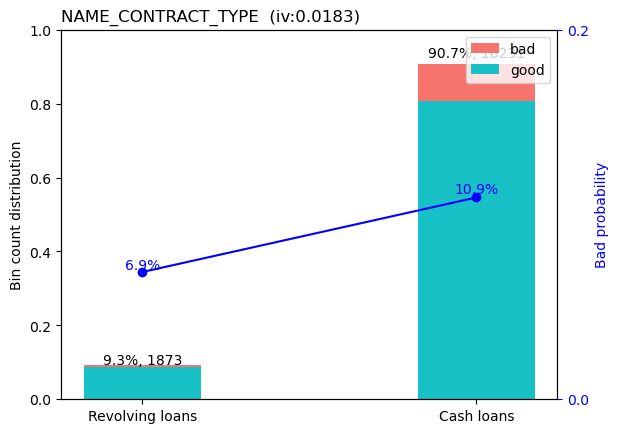

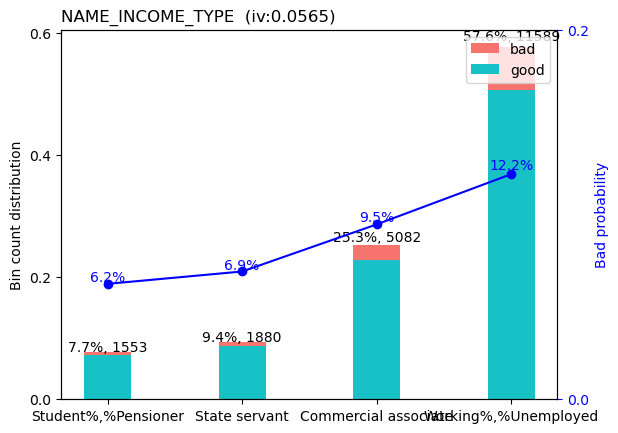

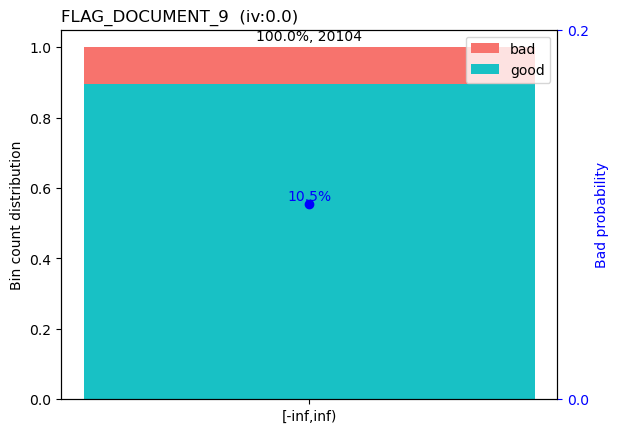

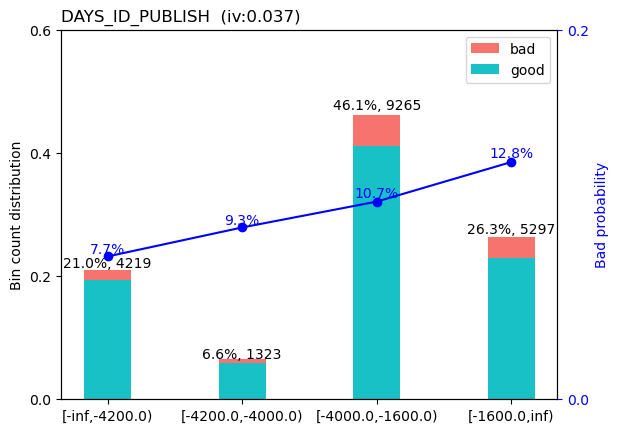

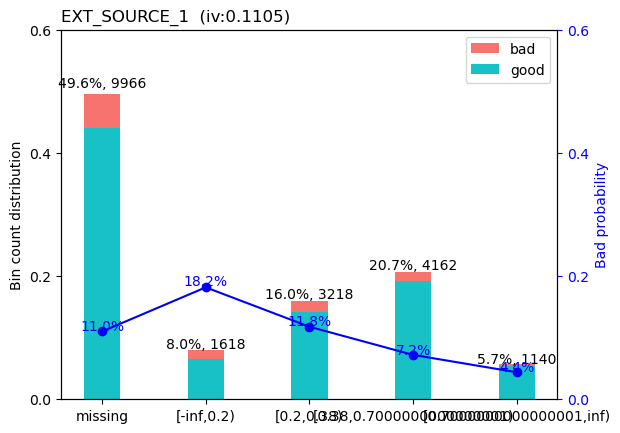

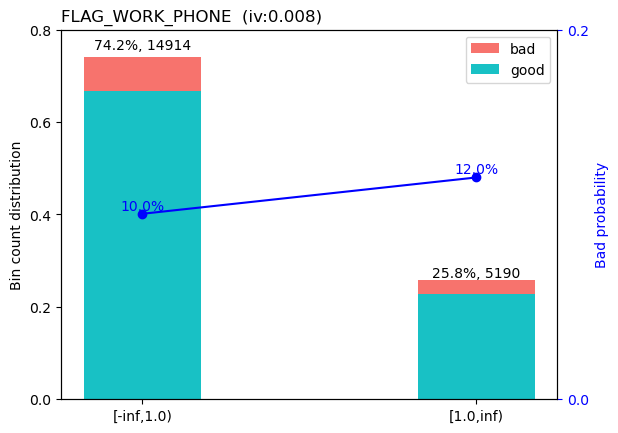

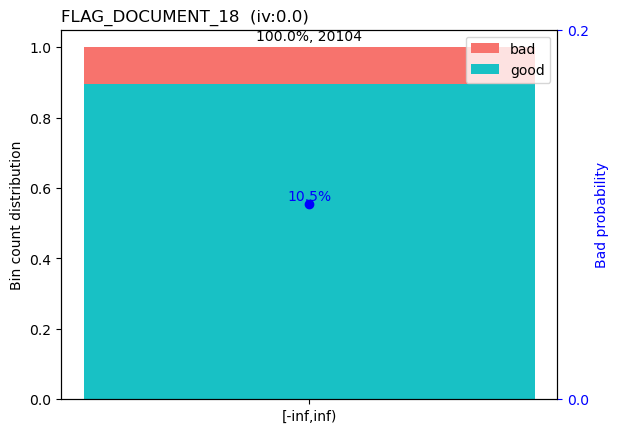

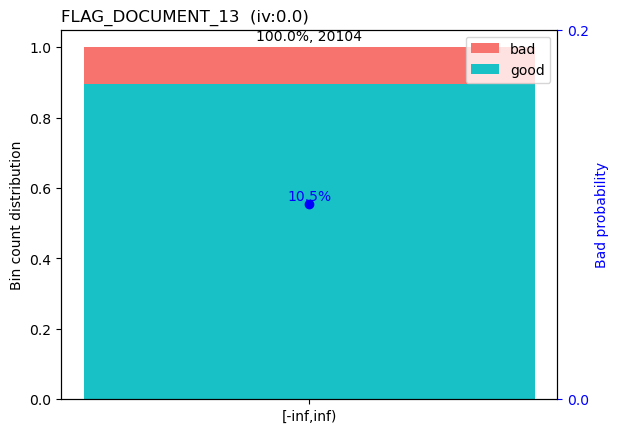

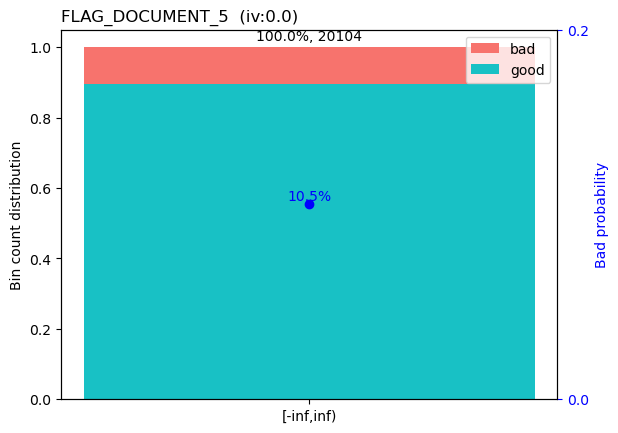

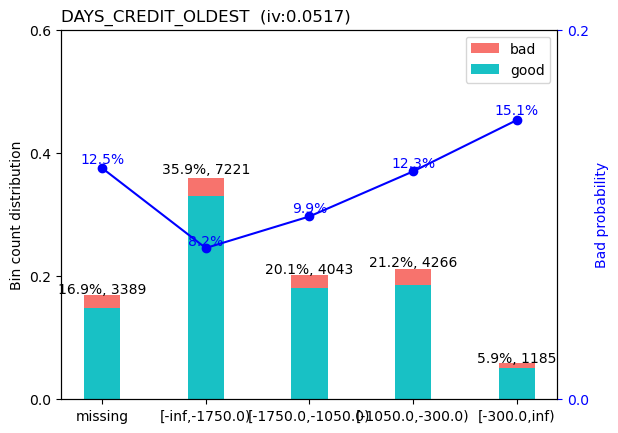

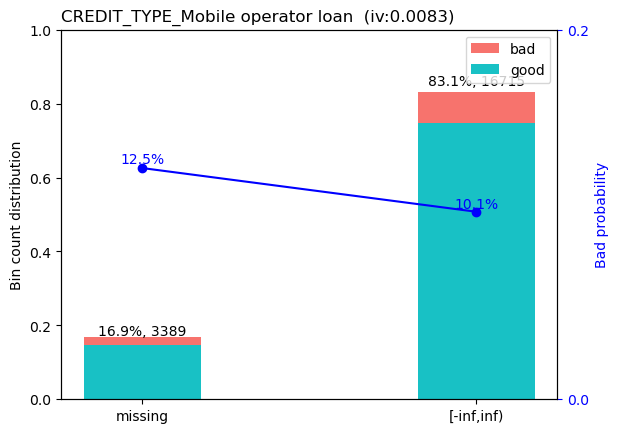

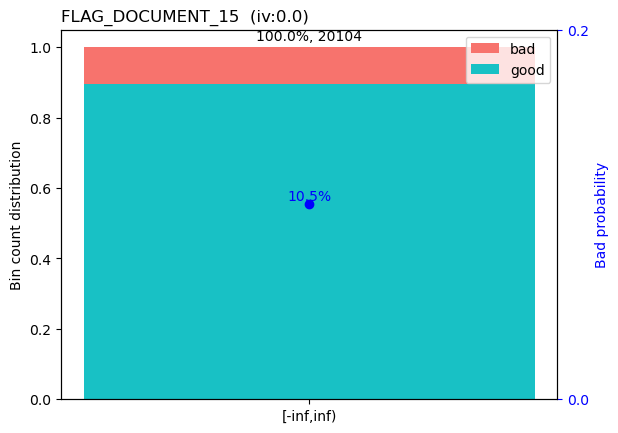

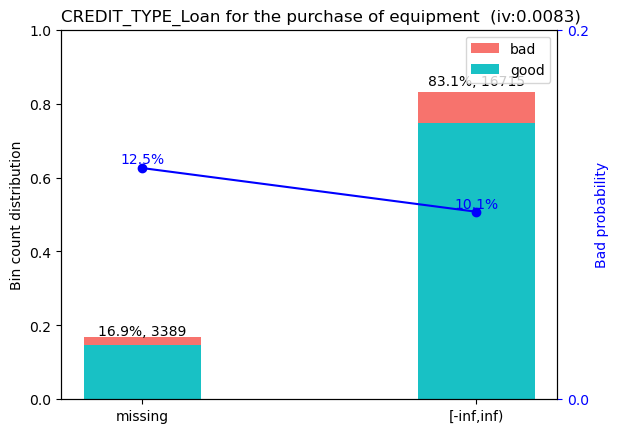

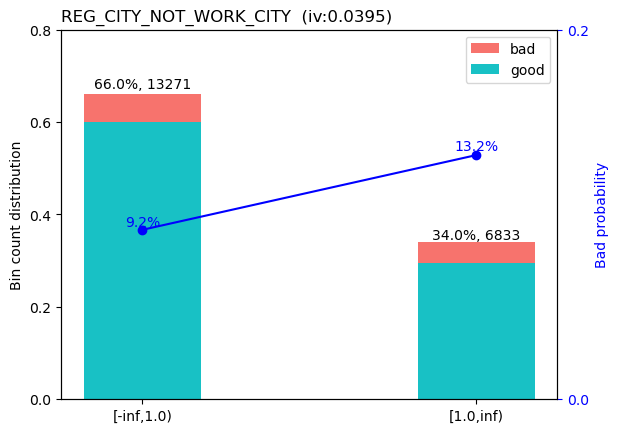

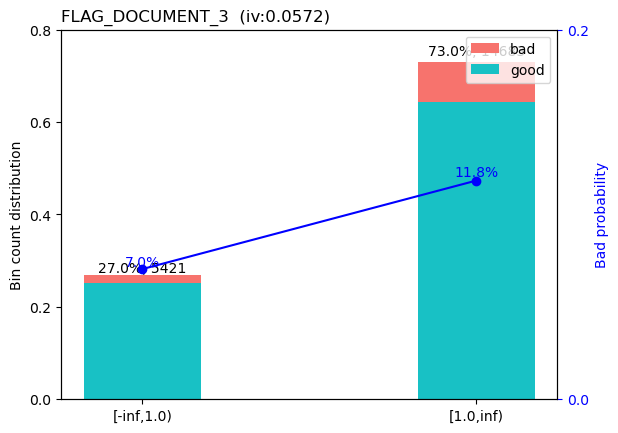

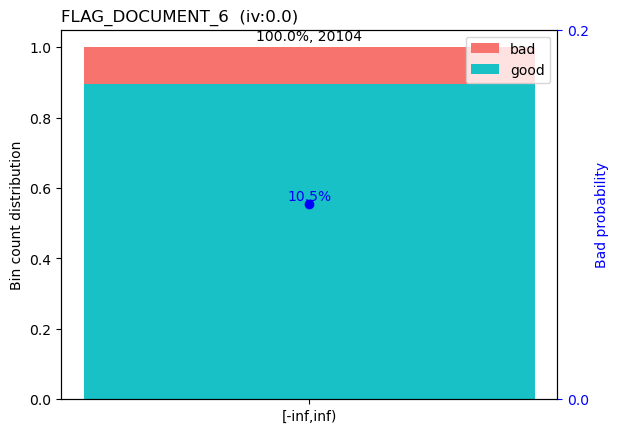

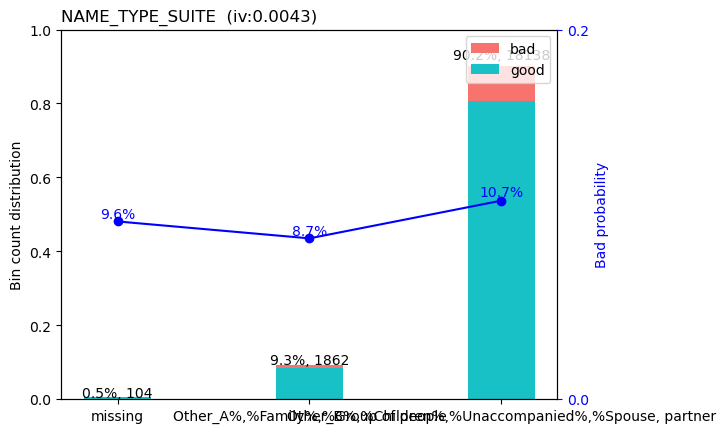

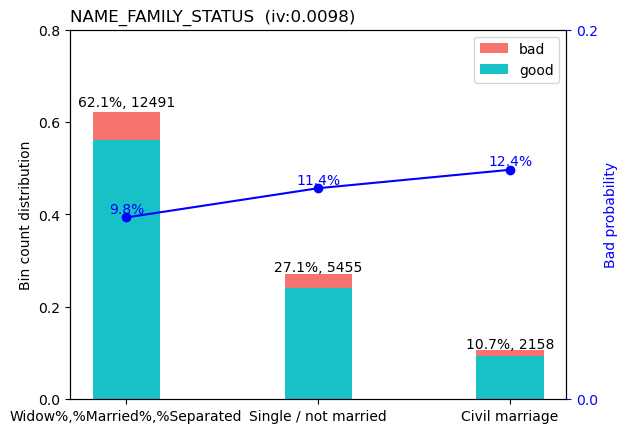

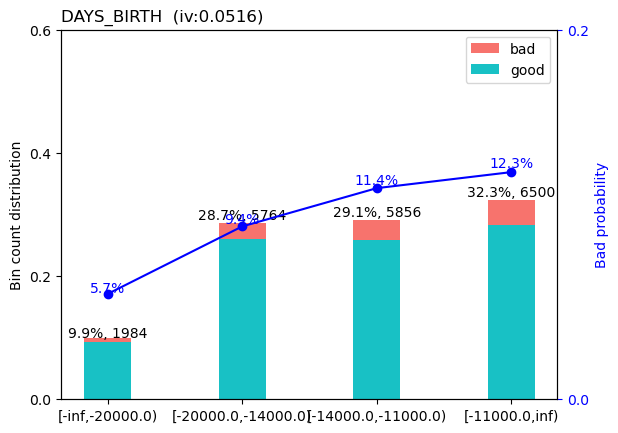

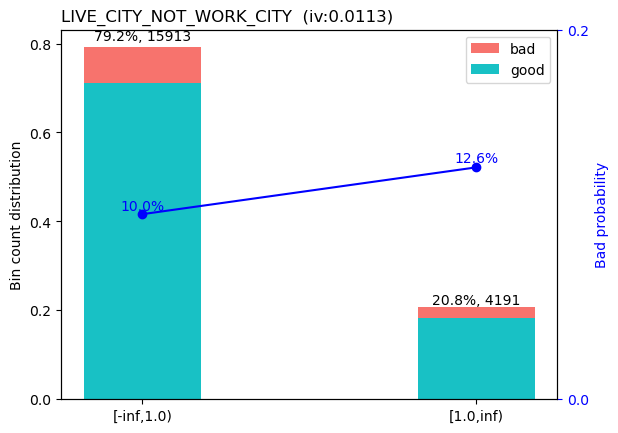

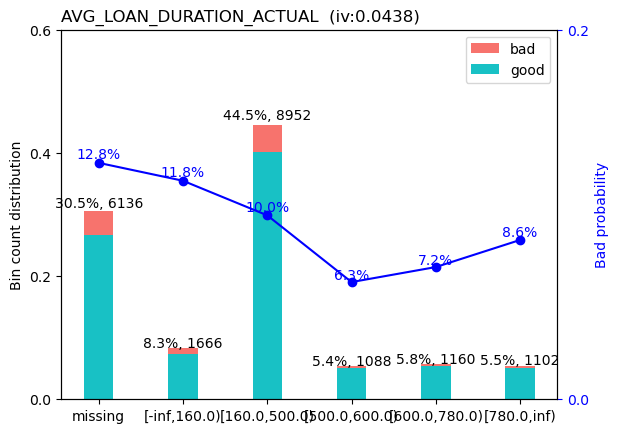

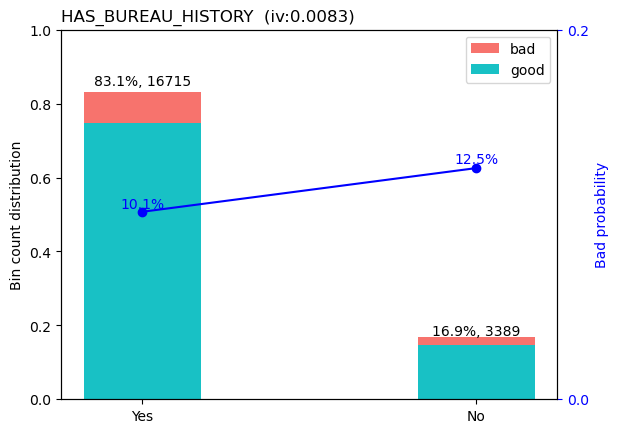

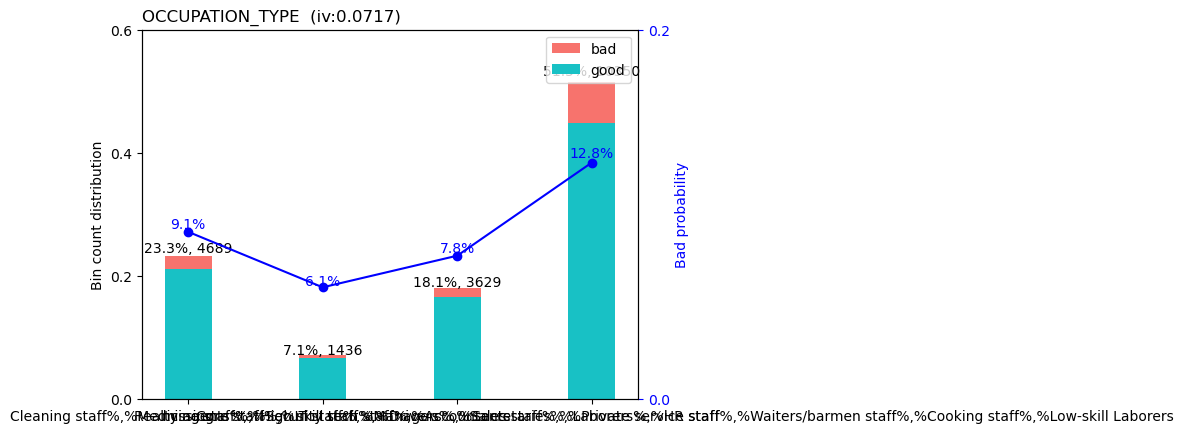

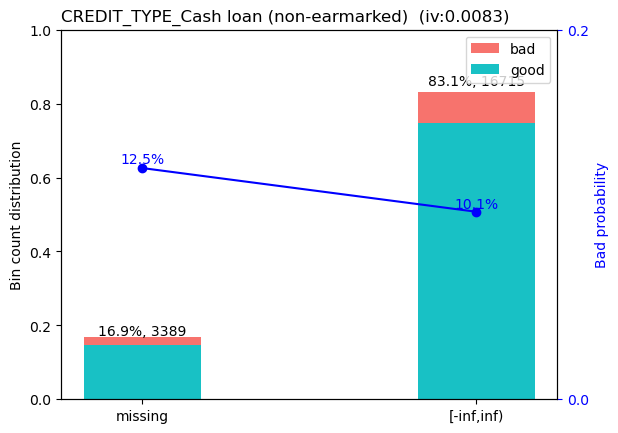

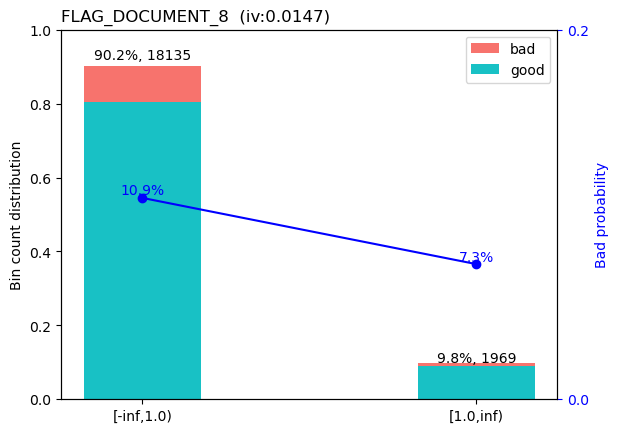

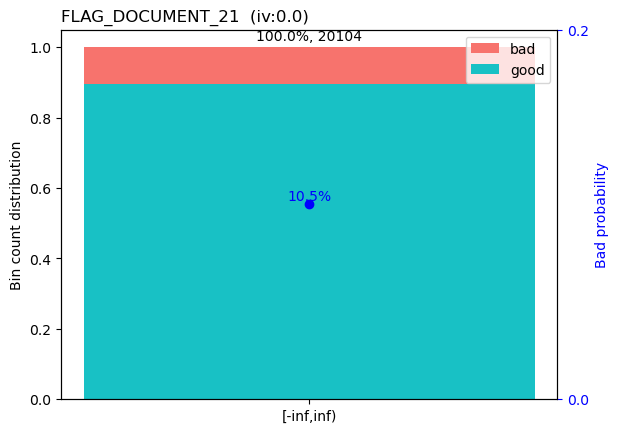

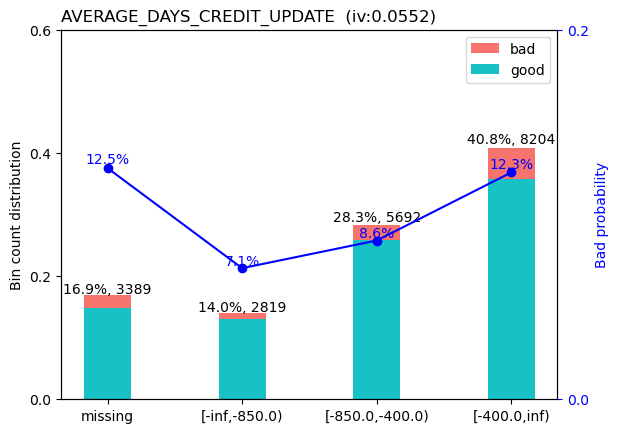

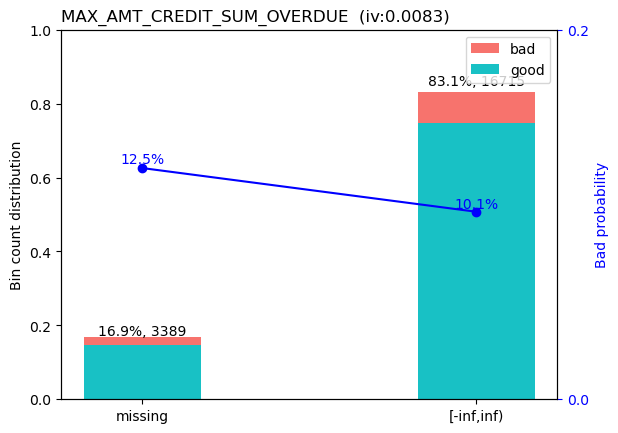

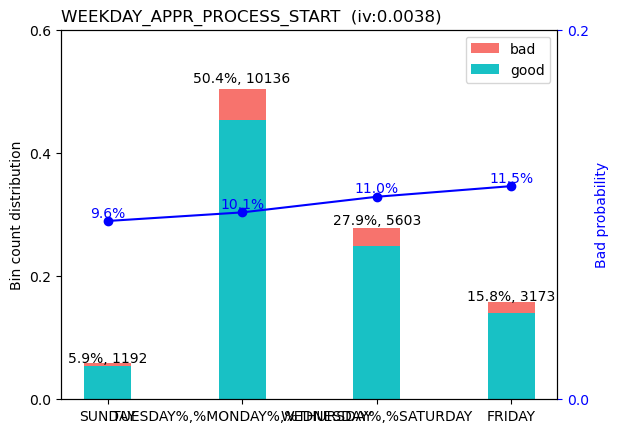

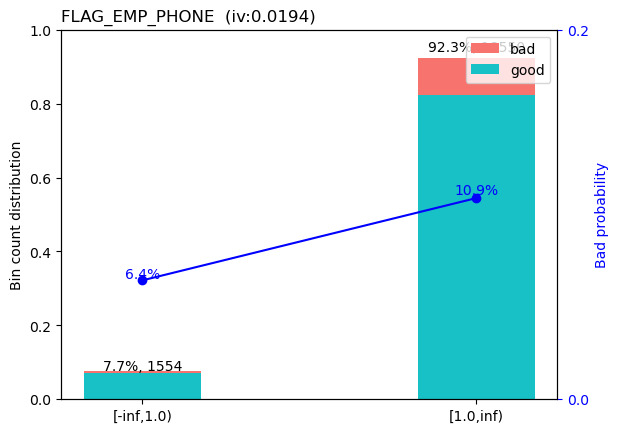

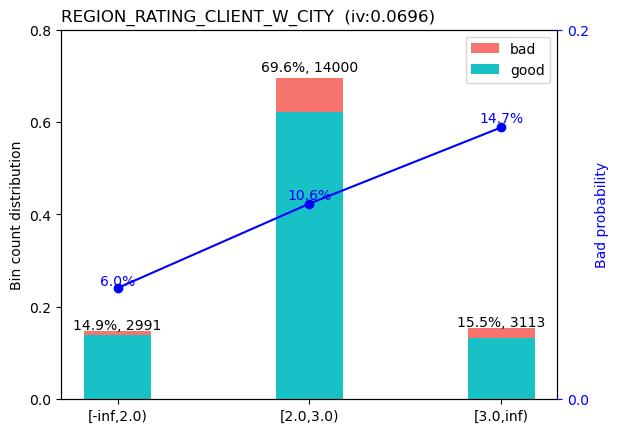

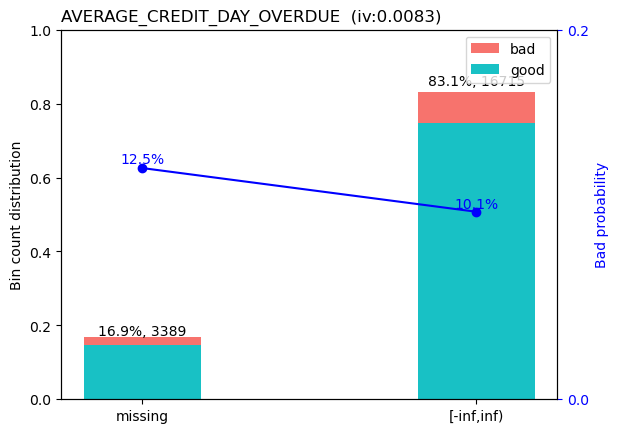

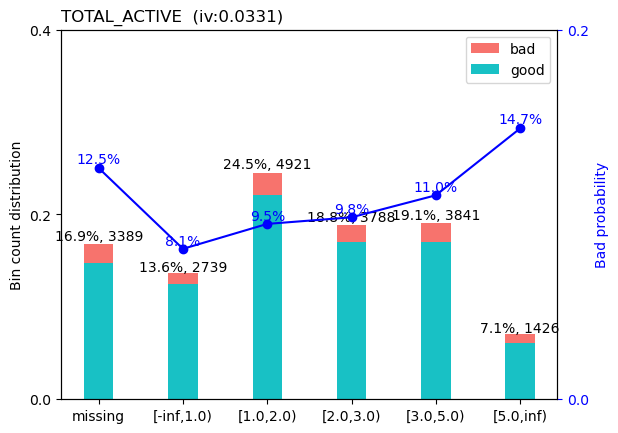

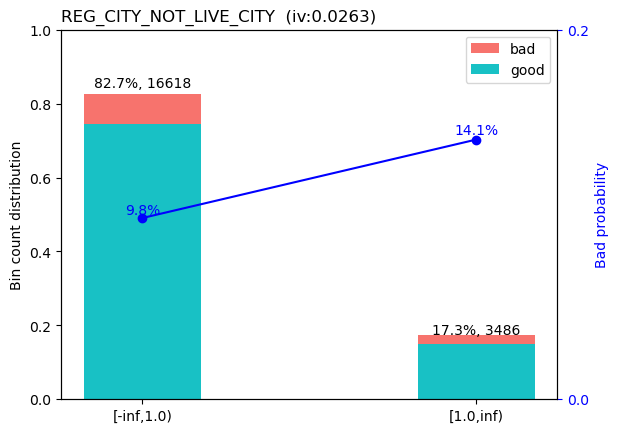

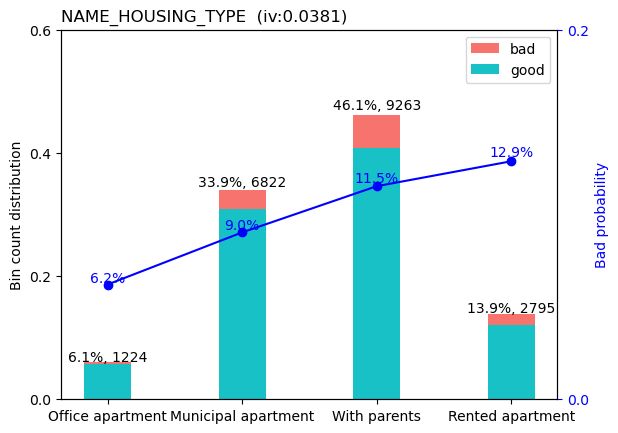

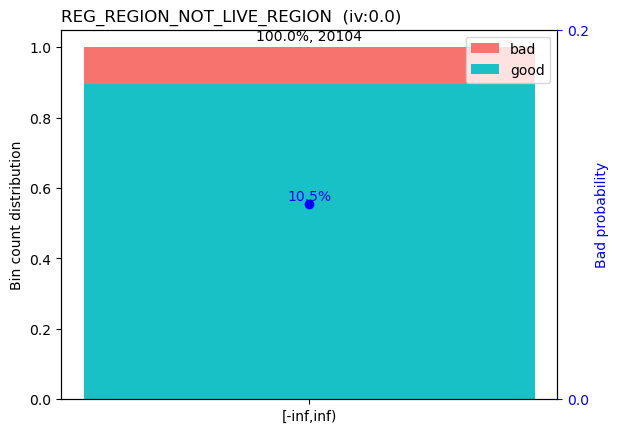

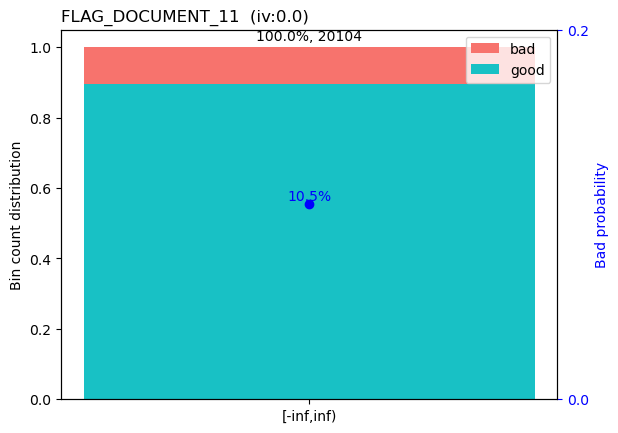

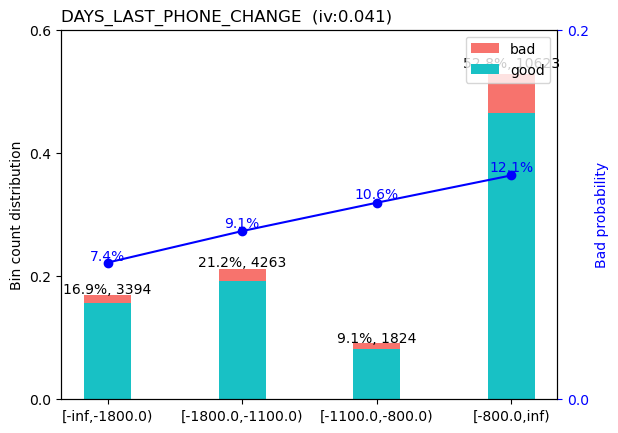

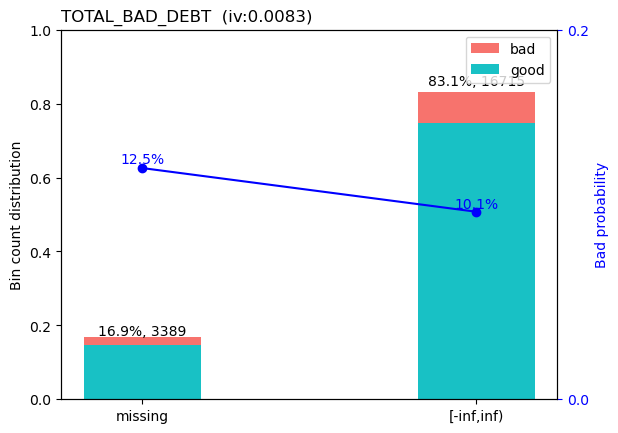

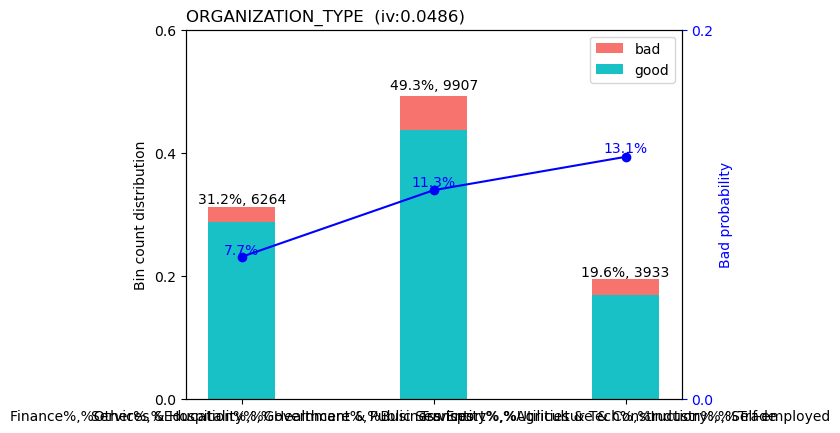

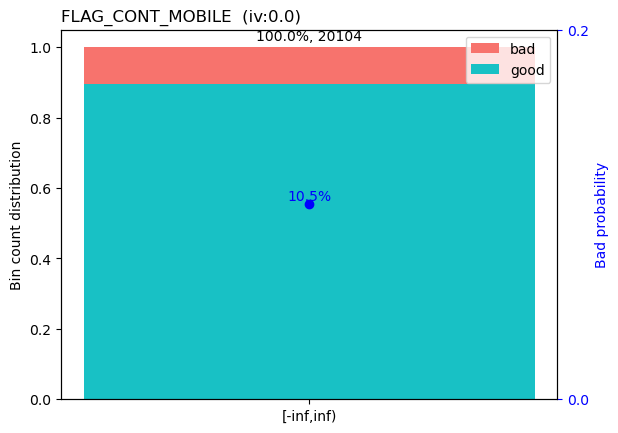

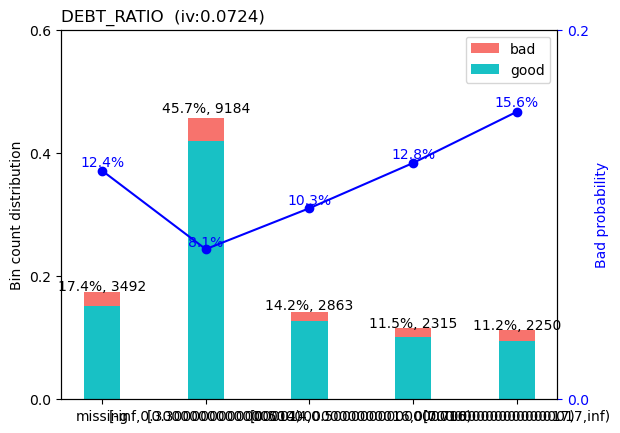

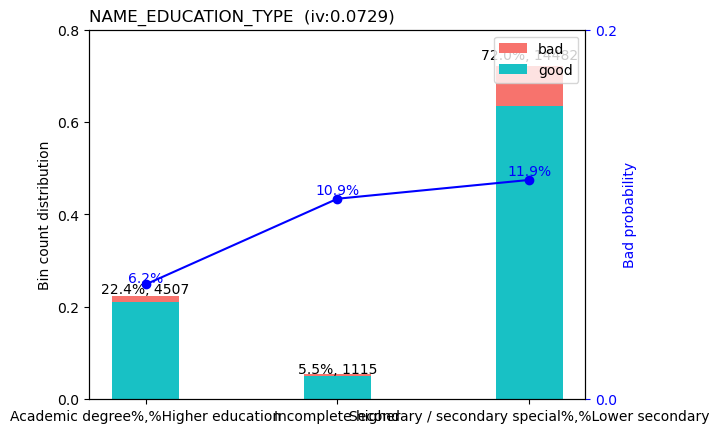

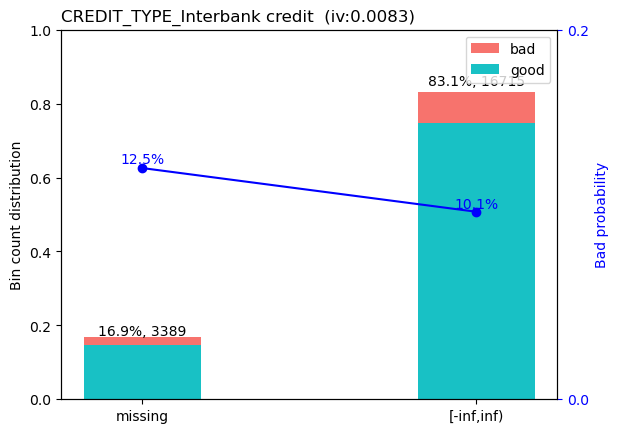

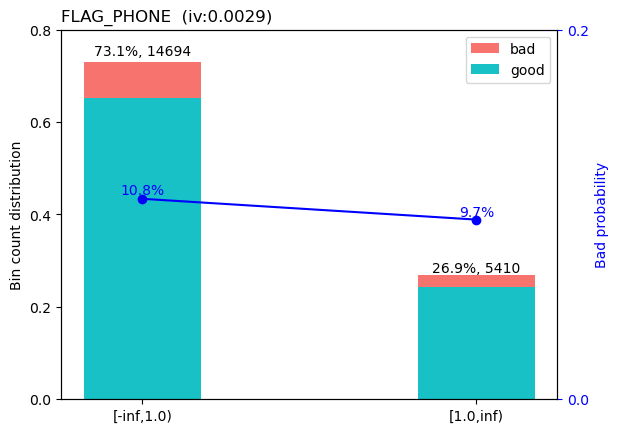

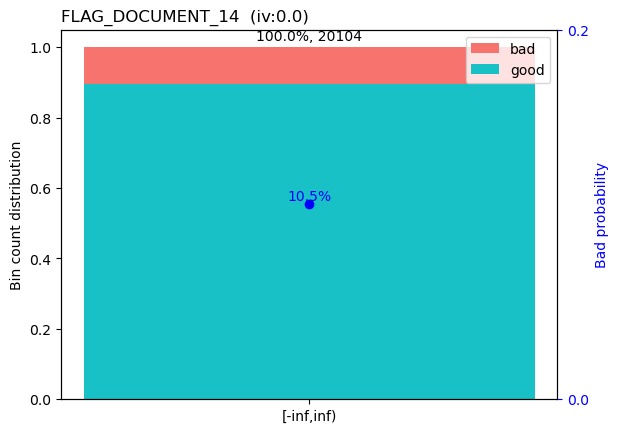

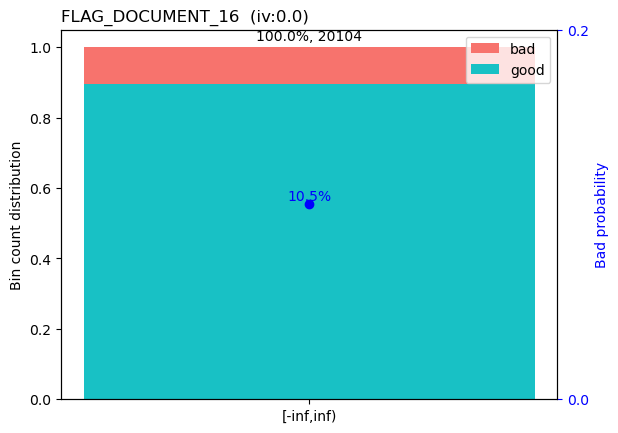

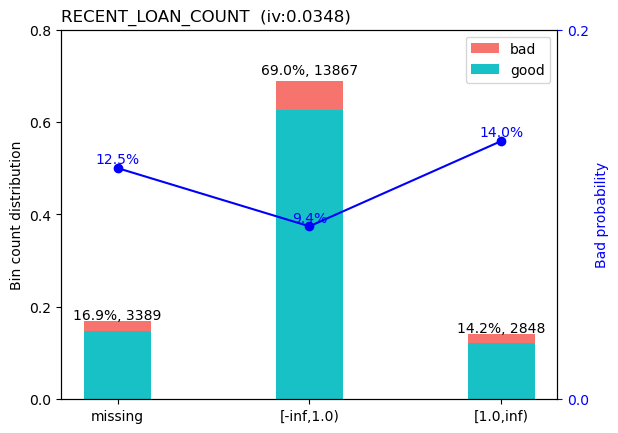

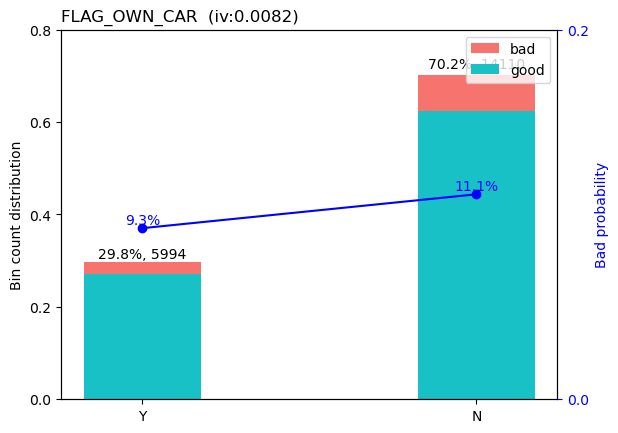

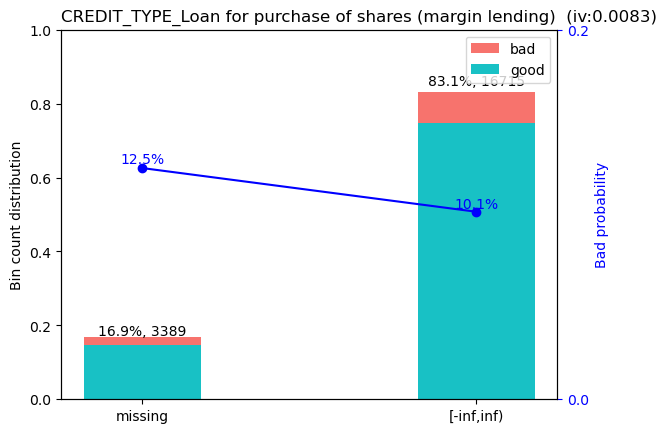

In [27]:
sc.woebin_plot(bins)

In [28]:
#STOPPED HEREEEEEEEEEEEEEEEEEEEEE

In [29]:
from IPython.display import display, HTML


import pandas as pd

iv_list = []

for var, table in bins.items():
    total_iv = table['bin_iv'].sum()
    
    iv_list.append({
        'variable': var,
        'IV': total_iv
    })

iv_df = pd.DataFrame(iv_list)

# sort ascending
iv_df = iv_df.sort_values(by='IV', ascending=False)

iv_df

display(HTML(iv_df.to_html(max_rows=1000)))

,variable,IV
4,EXT_SOURCE_1,0.110458
42,NAME_EDUCATION_TYPE,0.072888
41,DEBT_RATIO,0.072383
22,OCCUPATION_TYPE,0.071723
30,REGION_RATING_CLIENT_W_CITY,0.069631
14,FLAG_DOCUMENT_3,0.057160
1,NAME_INCOME_TYPE,0.056504
26,AVERAGE_DAYS_CREDIT_UPDATE,0.055164
9,DAYS_CREDIT_OLDEST,0.051714
18,DAYS_BIRTH,0.051575


In [30]:
from IPython.display import display, HTML


import pandas as pd

iv_list = []

for var, table in bins.items():
    total_iv = table['bin_iv'].sum()
    
    iv_list.append({
        'variable': var,
        'IV': total_iv
    })

iv_df = pd.DataFrame(iv_list)

# sort ascending
iv_df = iv_df.sort_values(by='IV', ascending=False)

iv_df

display(HTML(iv_df.to_html(max_rows=16)))

,variable,IV
4,EXT_SOURCE_1,0.110458
42,NAME_EDUCATION_TYPE,0.072888
41,DEBT_RATIO,0.072383
22,OCCUPATION_TYPE,0.071723
30,REGION_RATING_CLIENT_W_CITY,0.069631
14,FLAG_DOCUMENT_3,0.057160
1,NAME_INCOME_TYPE,0.056504
26,AVERAGE_DAYS_CREDIT_UPDATE,0.055164
...,...,...
8,FLAG_DOCUMENT_5,0.000000


In [31]:
# bins['TOTAL_CREDIT_LIMIT'][['bin', 'bin_iv']]

In [32]:
# bins['TOTAL_CREDIT_LIMIT']['bin_iv'].sum()

In [33]:
# 1. Get top 15 variables based on IV
top_15_vars = iv_df.head(15)['variable'].tolist()

# (Optional) check them
print(top_15_vars)


['EXT_SOURCE_1', 'NAME_EDUCATION_TYPE', 'DEBT_RATIO', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT_W_CITY', 'FLAG_DOCUMENT_3', 'NAME_INCOME_TYPE', 'AVERAGE_DAYS_CREDIT_UPDATE', 'DAYS_CREDIT_OLDEST', 'DAYS_BIRTH', 'ORGANIZATION_TYPE', 'AVG_LOAN_DURATION_ACTUAL', 'DAYS_LAST_PHONE_CHANGE', 'REG_CITY_NOT_WORK_CITY', 'NAME_HOUSING_TYPE']


In [34]:
# 2. Create a copy of iteration1df
iteration1df_top15varonly = iteration1df.copy()
# 3. Keep only top 15 variables + TARGET
selected_cols = top_15_vars + ['TARGET']   # ensure TARGET is included

iteration1df_top15varonly = iteration1df_top15varonly[selected_cols]

In [35]:
print(iteration1df_top15varonly.shape)
iteration1df_top15varonly.head()

(20104, 16)


,EXT_SOURCE_1,NAME_EDUCATION_TYPE,DEBT_RATIO,OCCUPATION_TYPE,REGION_RATING_CLIENT_W_CITY,FLAG_DOCUMENT_3,NAME_INCOME_TYPE,AVERAGE_DAYS_CREDIT_UPDATE,DAYS_CREDIT_OLDEST,DAYS_BIRTH,ORGANIZATION_TYPE,AVG_LOAN_DURATION_ACTUAL,DAYS_LAST_PHONE_CHANGE,REG_CITY_NOT_WORK_CITY,NAME_HOUSING_TYPE,TARGET
0,NaN,Secondary / secondary special,0.618278,Sales staff,2,1,Working,-314.666667,-1644.0,-11146,Self-employed,728.0,-468.0,0,Rented apartment,0
1,NaN,Secondary / secondary special,0.588972,NaN,2,1,Pensioner,-96.500000,-509.0,-21621,Other,NaN,0.0,0,Municipal apartment,0
2,NaN,Incomplete higher,0.000000,Sales staff,1,0,Working,-214.500000,-630.0,-7907,Trade,346.0,-725.0,0,With parents,0
3,0.563323,Secondary / secondary special,0.041532,Sales staff,2,1,Commercial associate,-474.916667,-2257.0,-10485,Business Entity,441.0,-1234.0,0,With parents,0
4,0.405564,Higher education,0.000000,Core staff,2,1,Commercial associate,-32.666667,-545.0,-10954,Other,NaN,-663.0,0,With parents,0


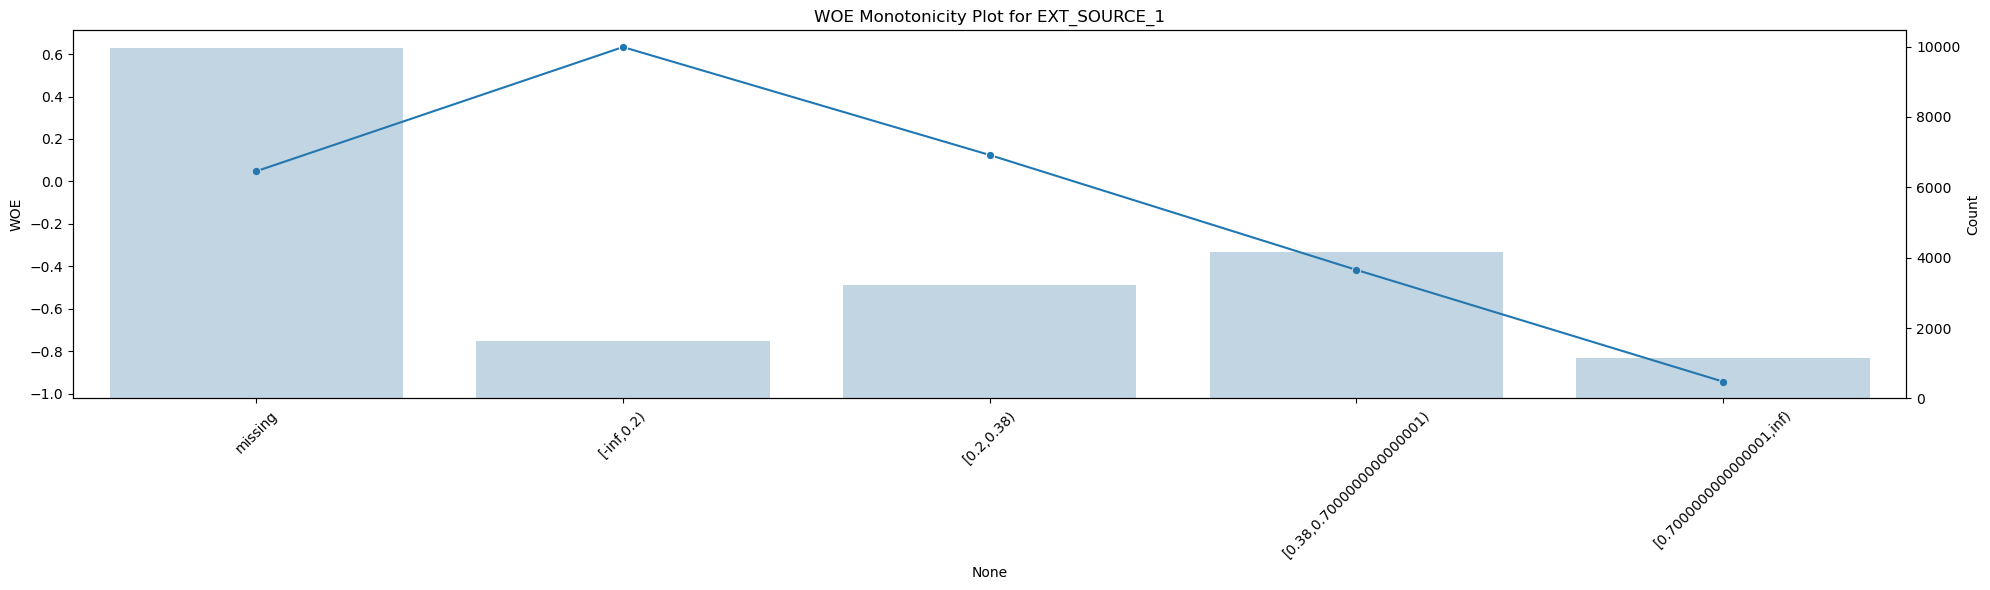

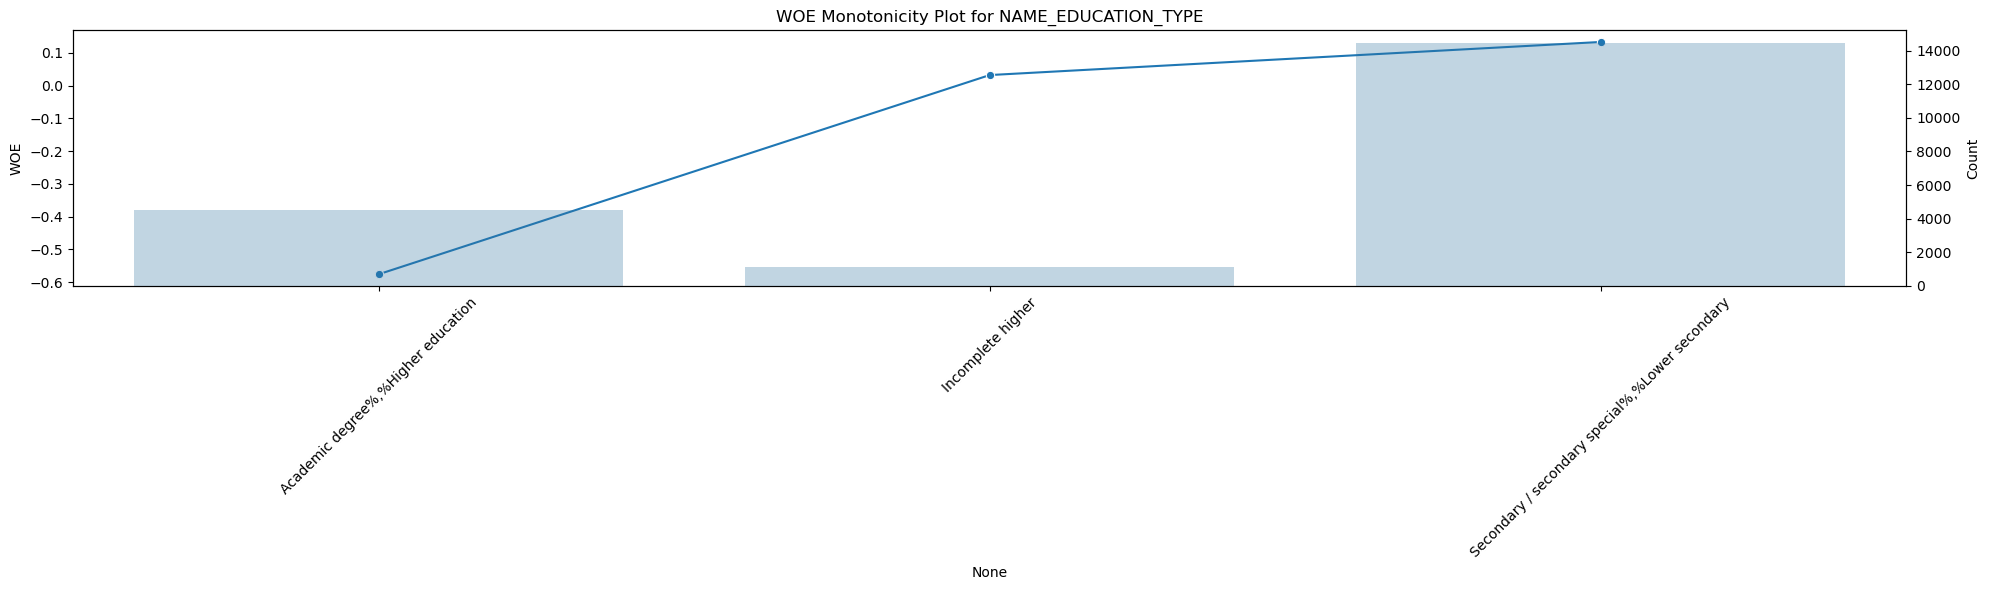

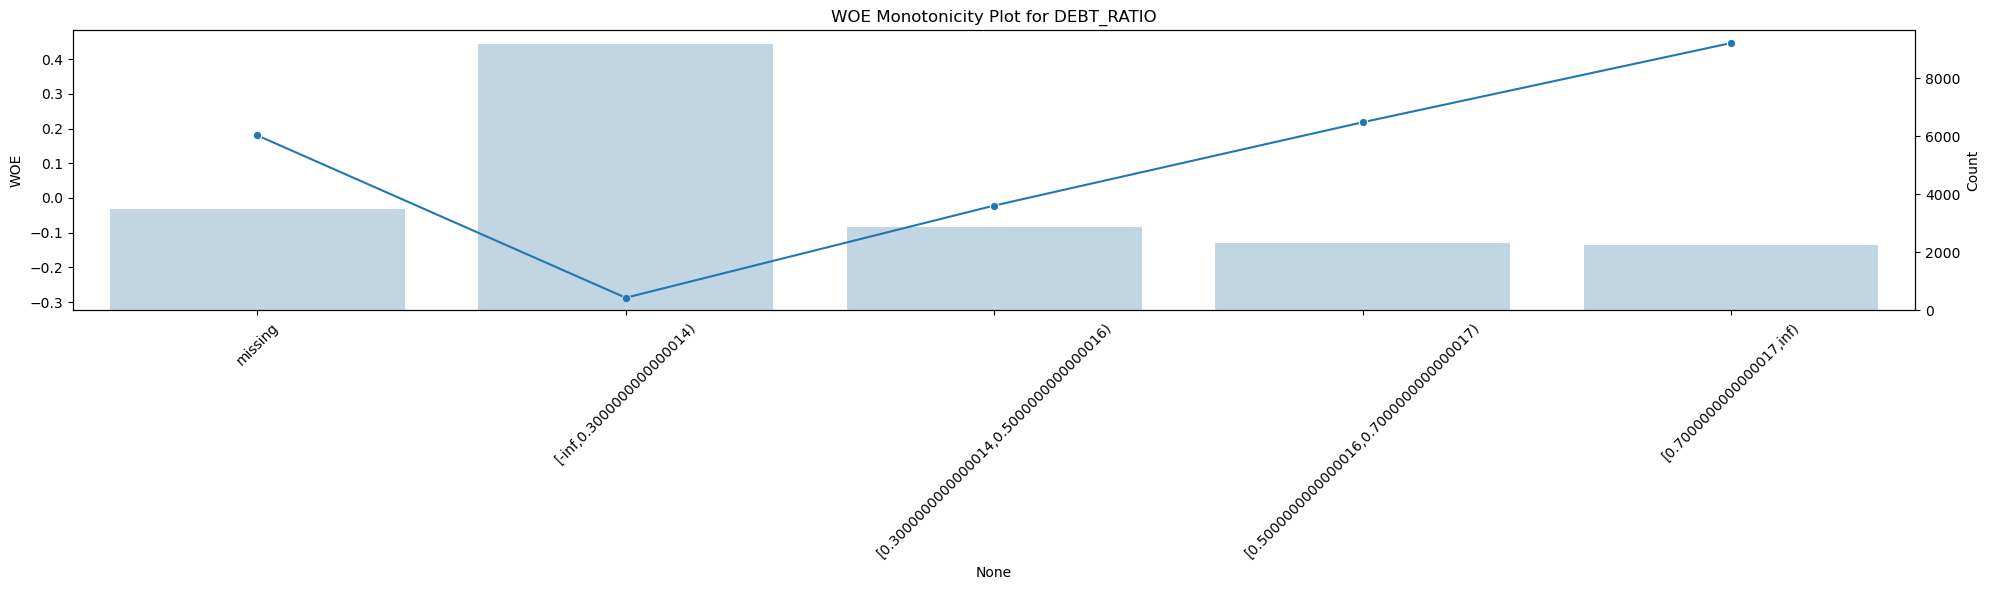

/var/folders/5_/5bgkd51n45sgbnmt71swhhsw0000gn/T/ipykernel_81510/1586950873.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


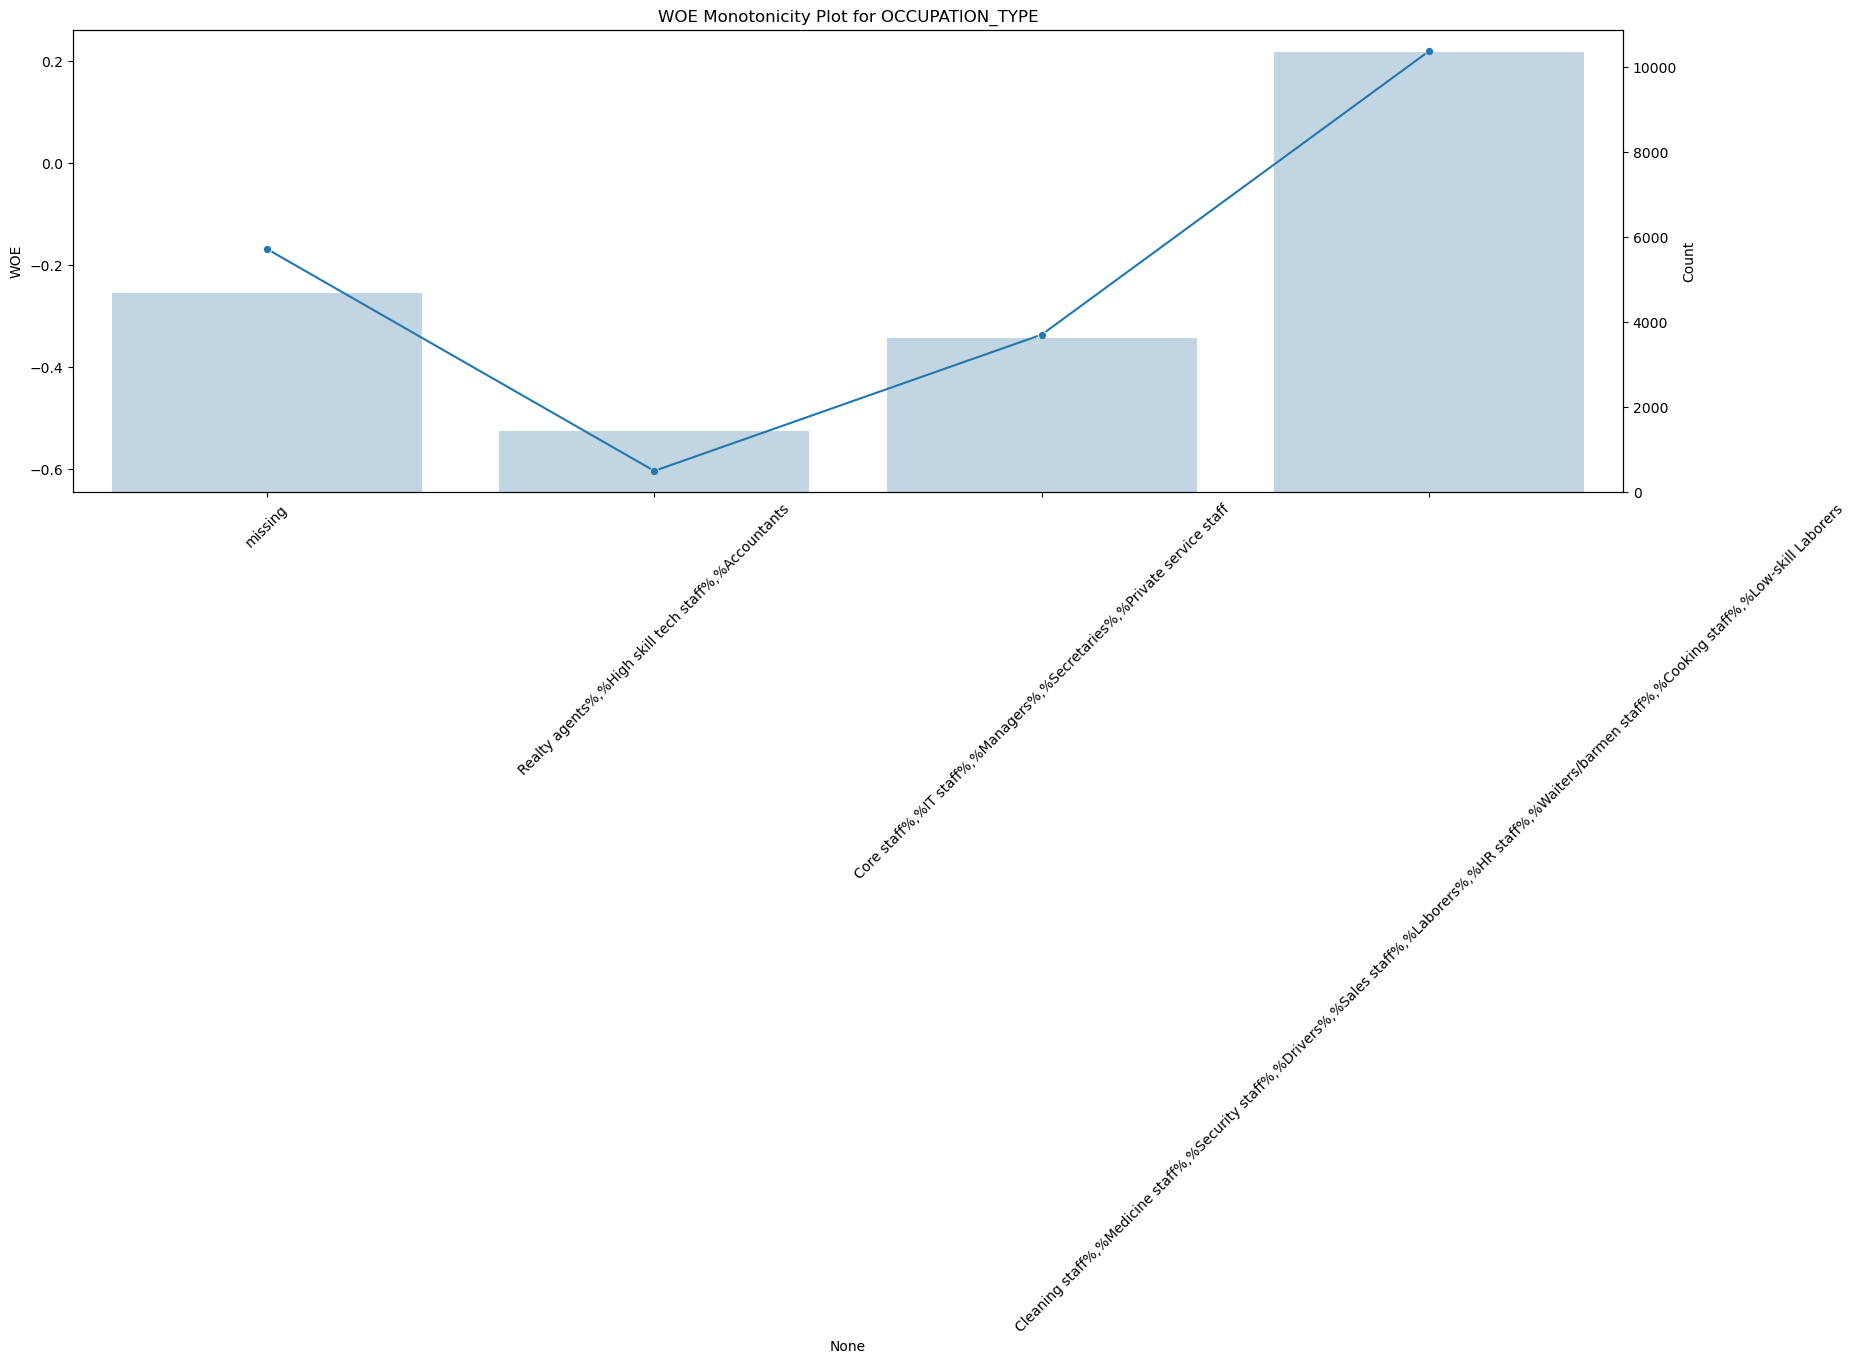

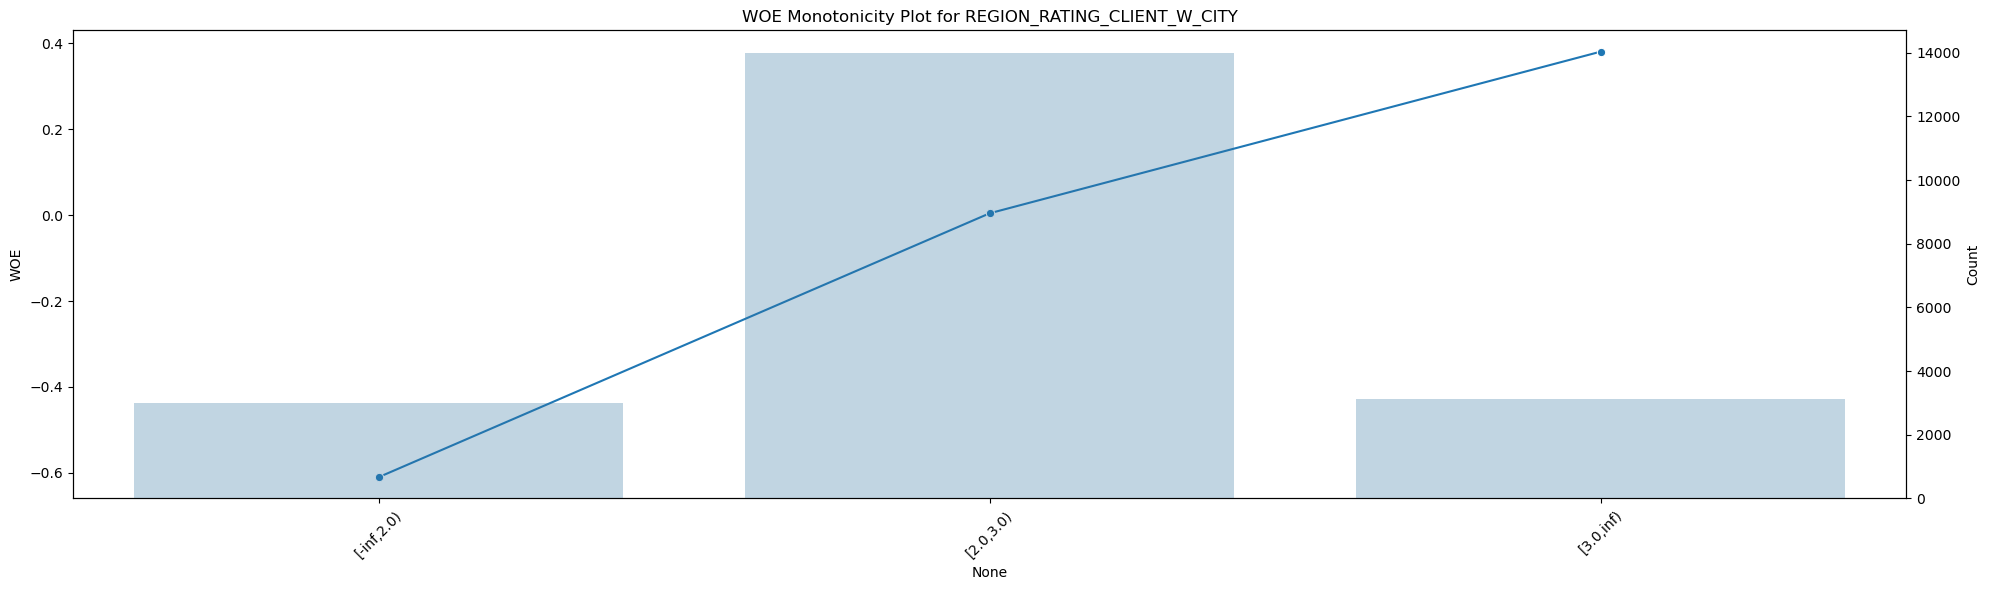

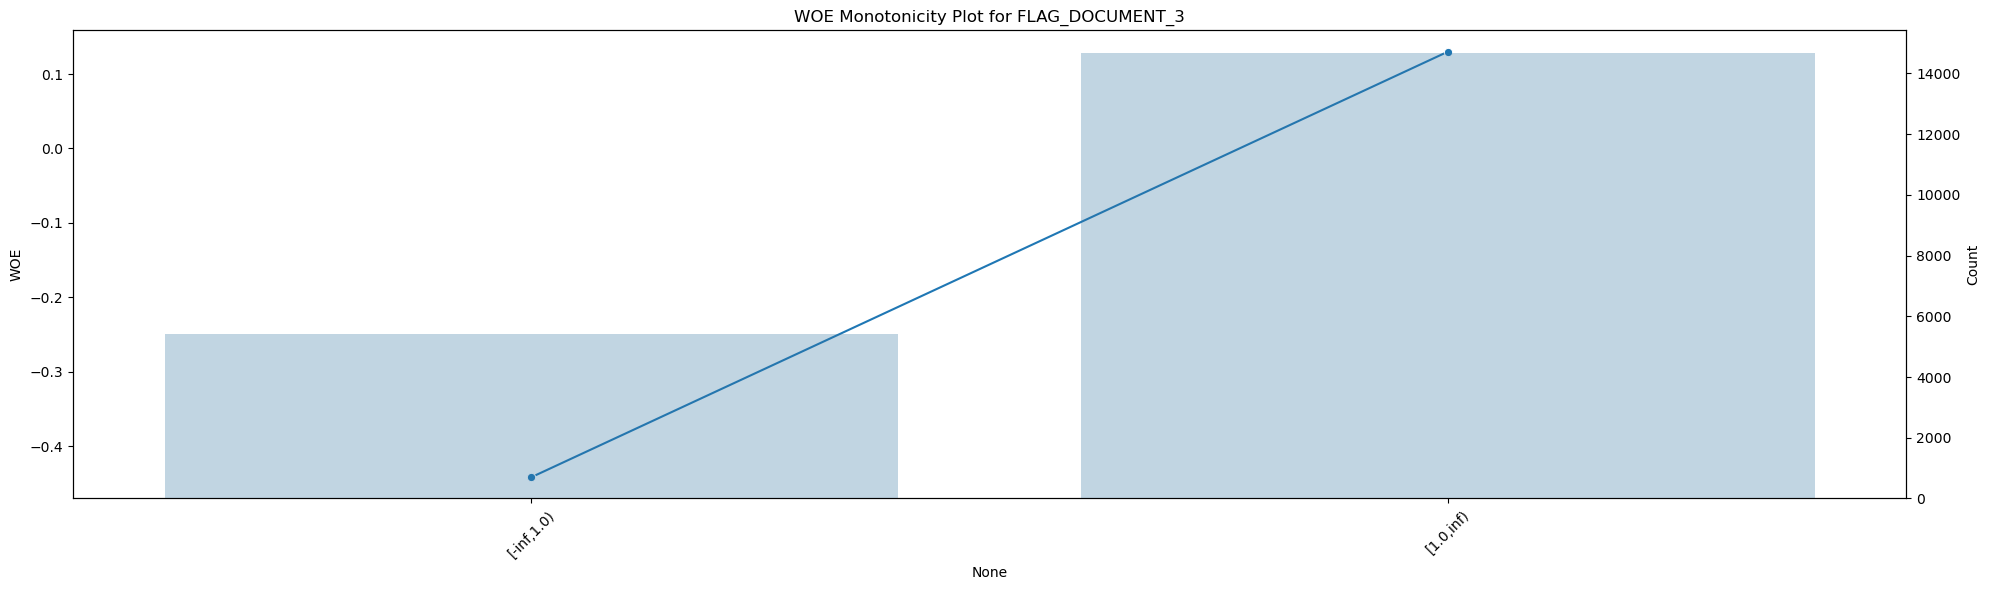

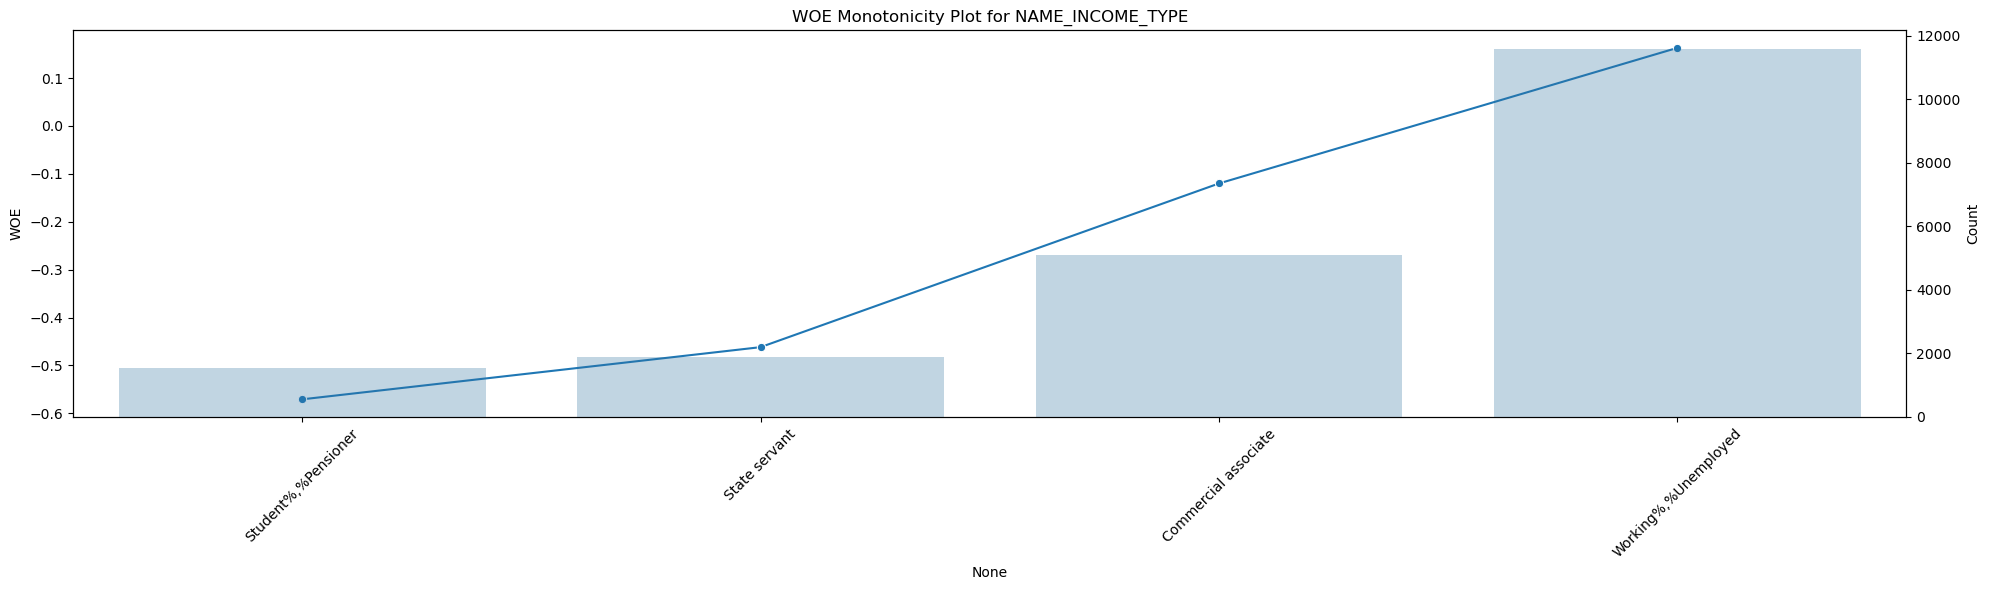

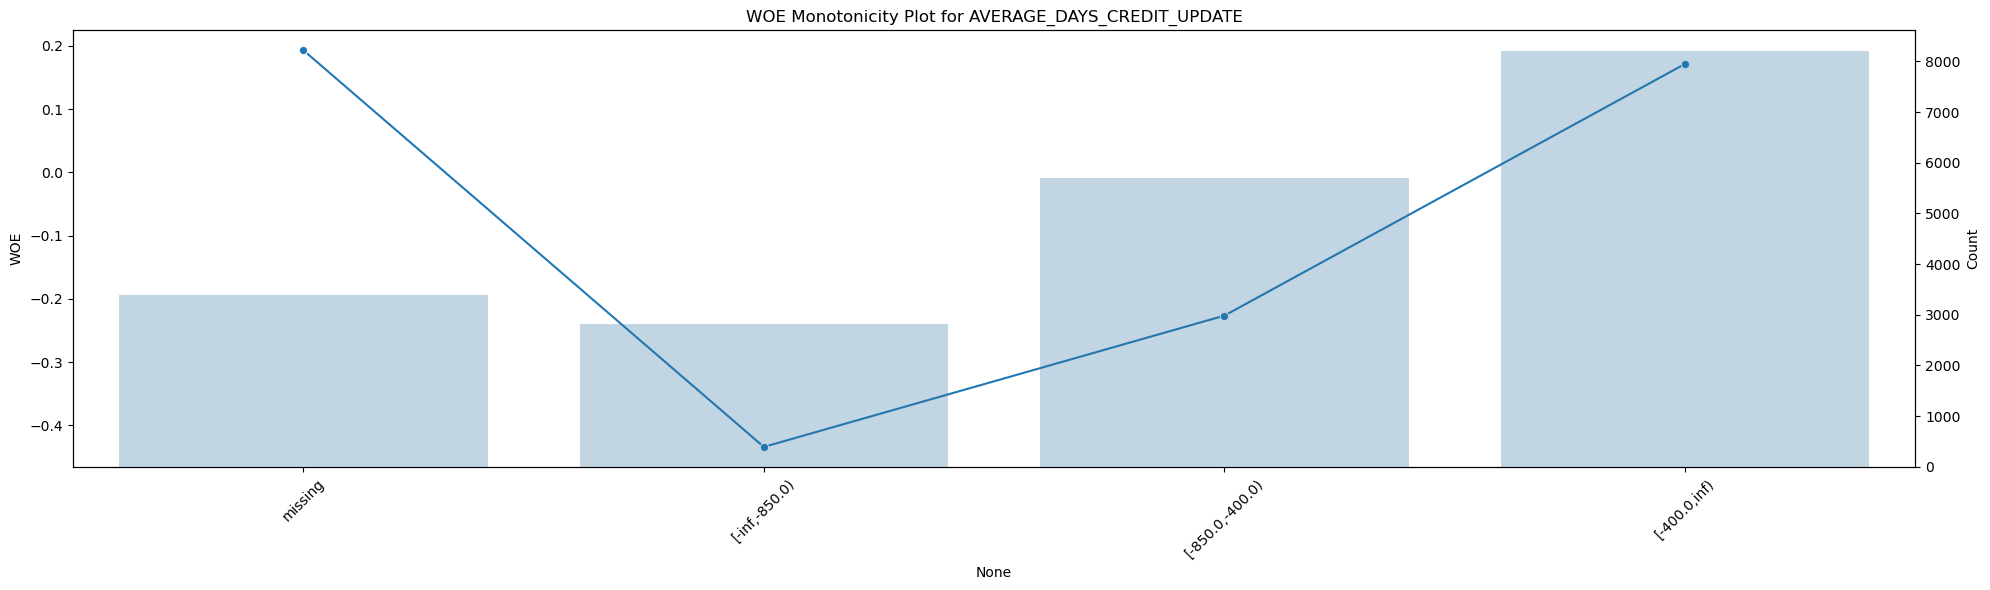

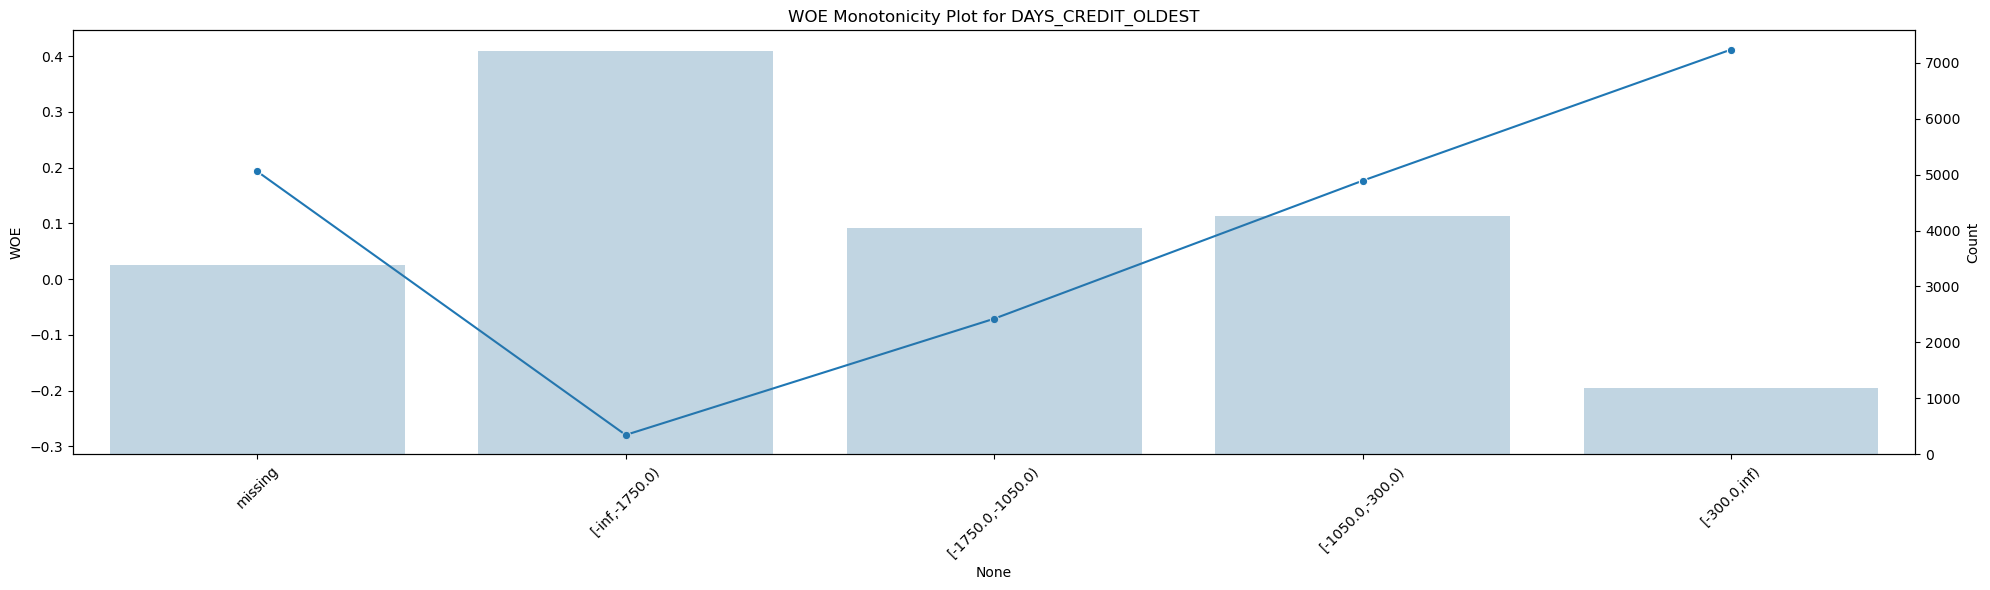

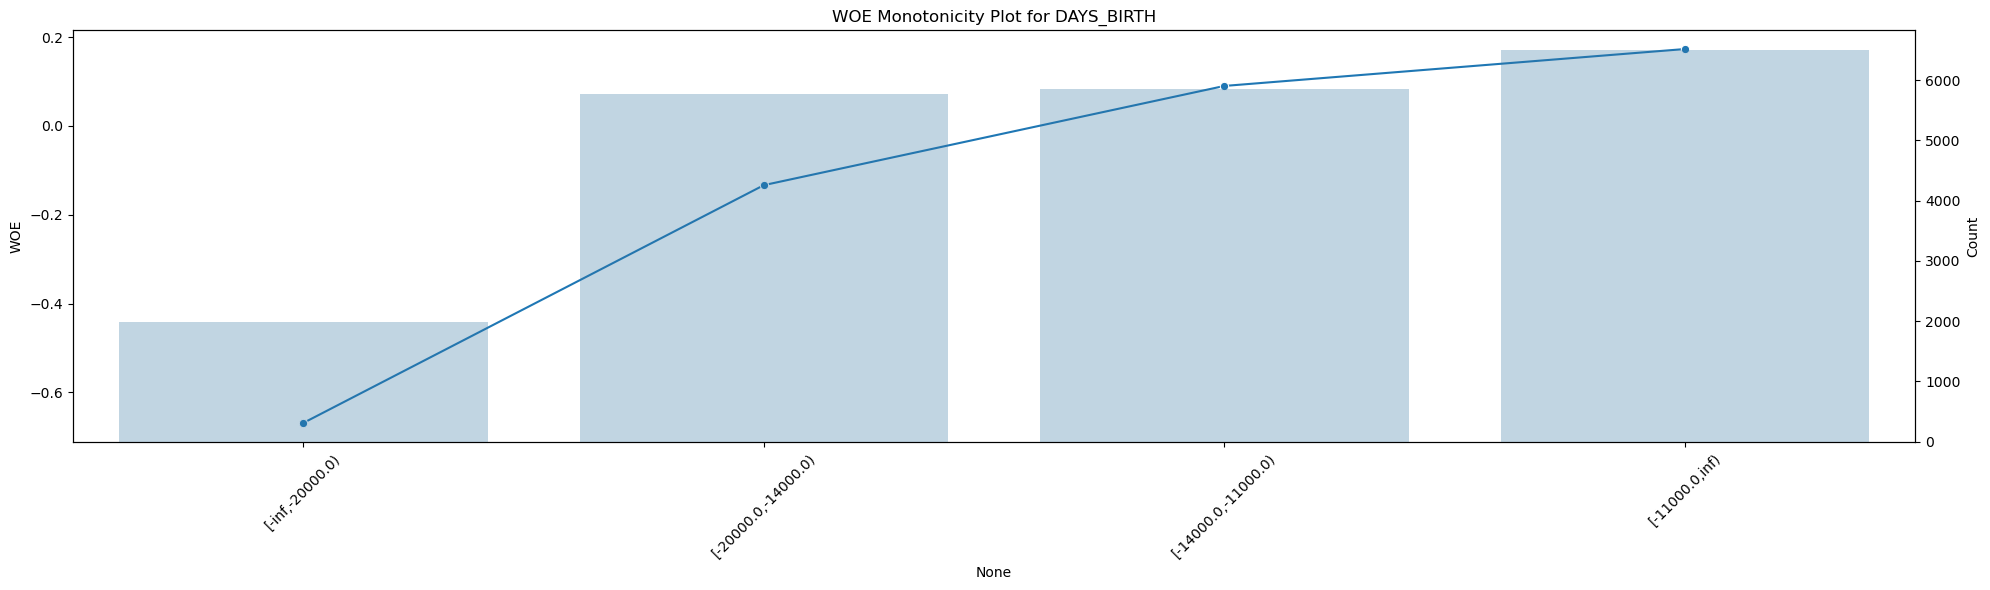

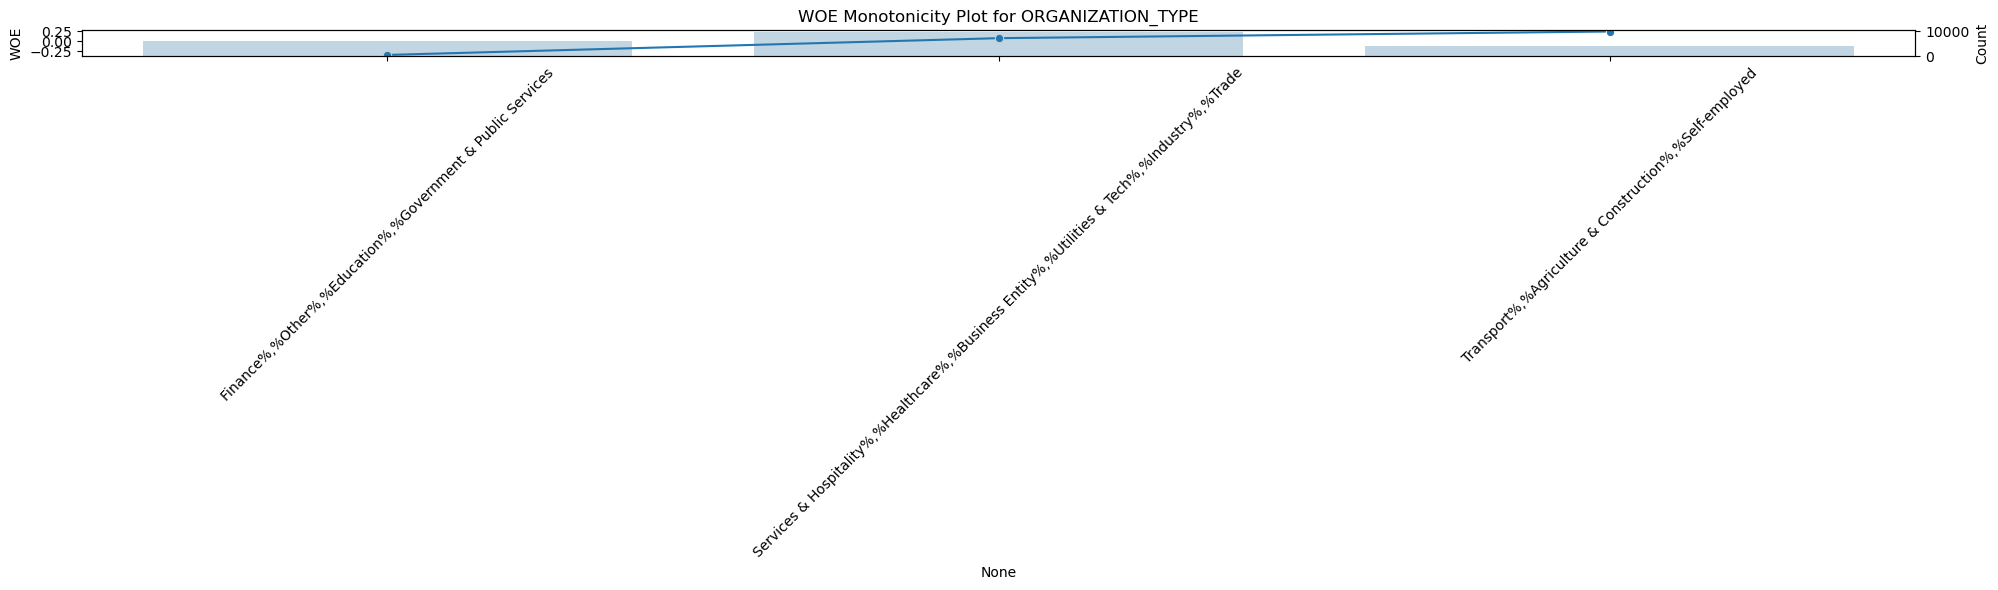

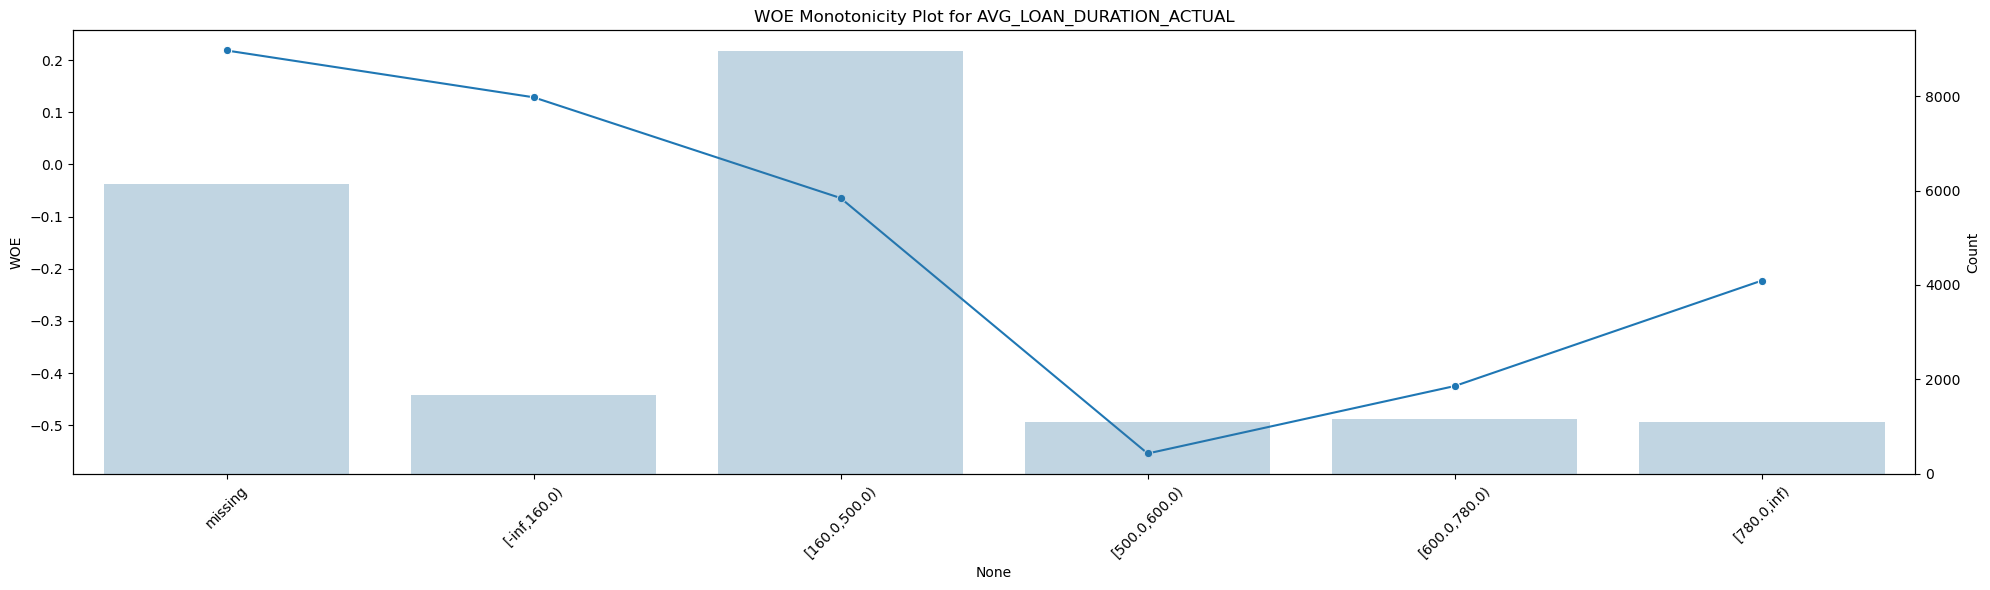

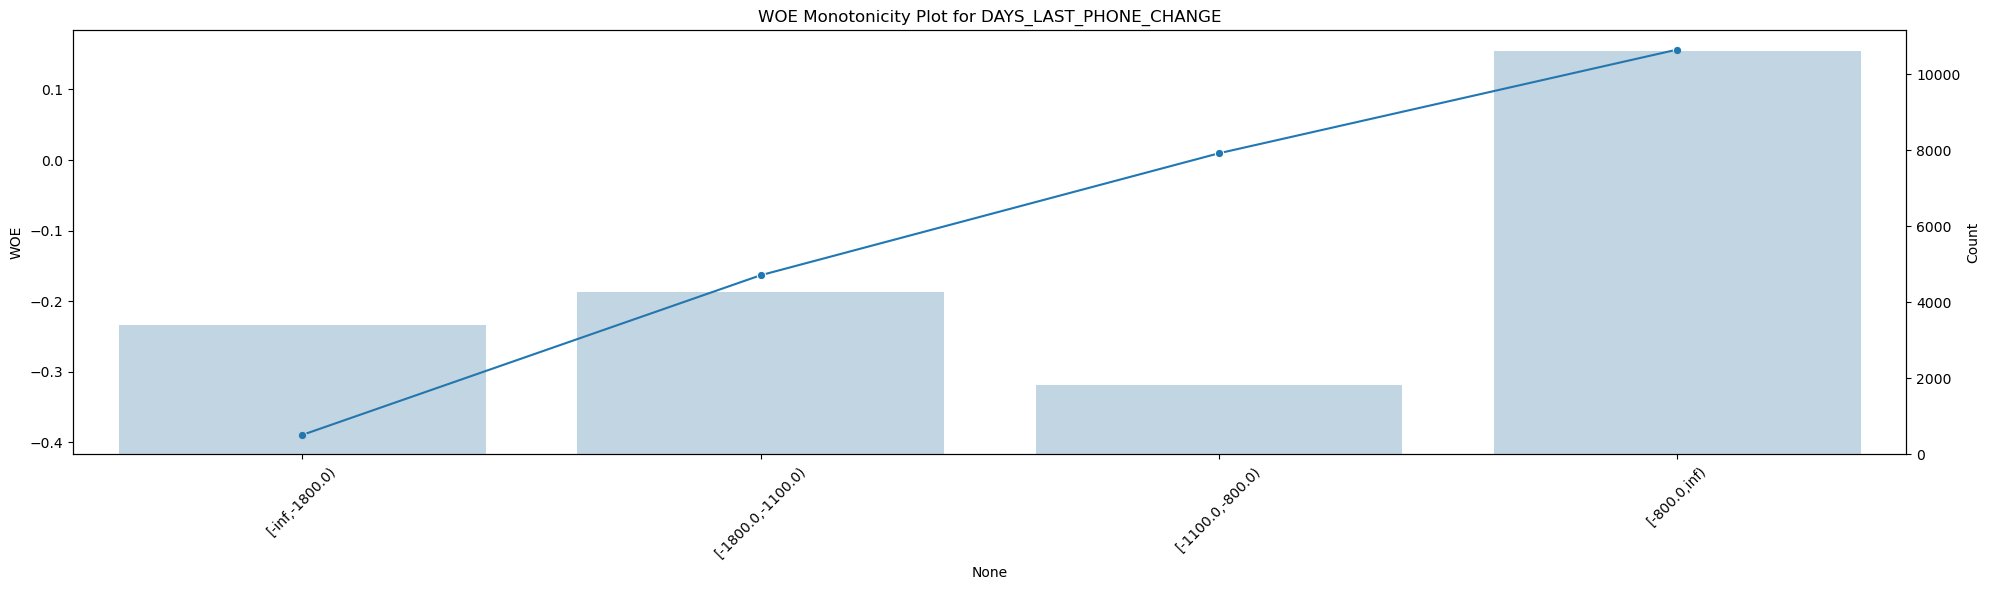

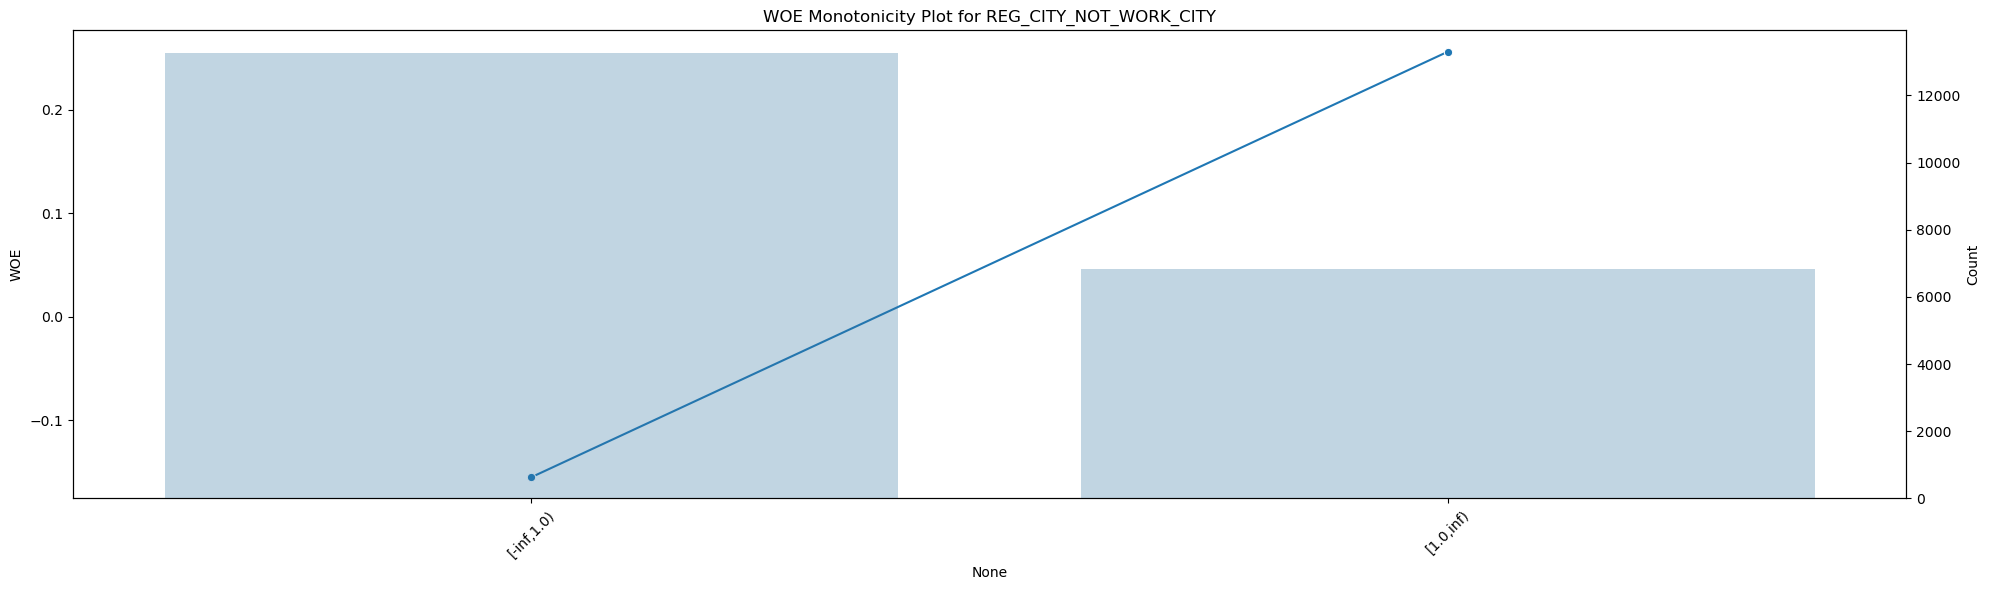

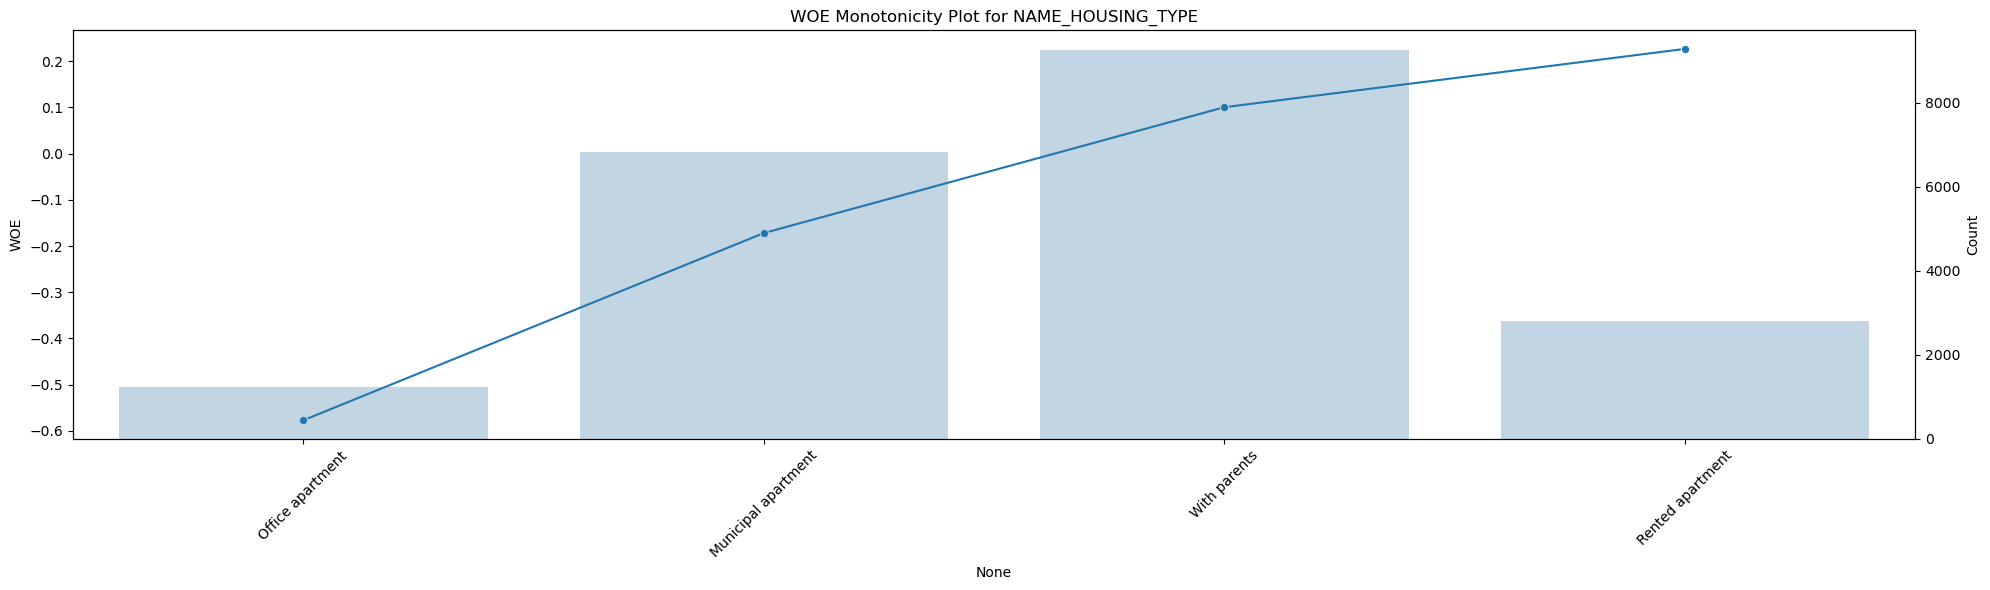

In [36]:
#CHECK FOR MONOTONICITY OF THE TOP 15 VAR/VARS INCLUDED IN THE LR MODEL
import matplotlib.pyplot as plt
import seaborn as sns

# # get top 15 variables
# top_15 = iv_df.head(15)['variable'].tolist()

# iteration1df_top15varonly

for variable in top_15_vars:
    
    # get bin table for each variable
    bin_df = bins[variable].copy()
    
    # create figure INSIDE loop
    fig, ax1 = plt.subplots(figsize=(20,6))

    # WOE line
    sns.lineplot(
        x=bin_df.index,
        y=bin_df['woe'],
        marker='o',
        ax=ax1
    )

    ax1.set_xticks(bin_df.index)
    ax1.set_xticklabels(bin_df['bin'], rotation=45)
    ax1.set_ylabel("WOE")

    # barplot for counts
    ax2 = ax1.twinx()

    sns.barplot(
        x=bin_df.index,
        y=bin_df['count'],
        alpha=0.3,
        ax=ax2
    )

    ax2.set_ylabel("Count")

    plt.title(f"WOE Monotonicity Plot for {variable}")
    plt.tight_layout()
    plt.show()


    # each bin has more than 5%
    # monotinicity
    # 

In [37]:
# COARSE CLASSING

import math 

# bins = sc.woebin(iteration1df_top15varonly,y='TARGET',breaks_list={'AVG_LOAN_DURATION_ACTUAL':[160, 500, math.inf ]})
# bins = sc.woebin(iteration1df_top15varonly,y='TARGET',breaks_list={'DAYS_BIRTH':[-20000, -14000, math.inf ]})

# breaks = {'NAME_EDUCATION_TYPE': [['Academic degree', 'Higher education'],['Incomplete higher', 'Secondary / secondary special', 'Lower secondary']]}
# breaks = { 'NAME_EDUCATION_TYPE': [ ['Academic degree', 'Higher education'], ['Incomplete higher', 'Secondary / secondary special', 'Lower secondary'], ] }

breaks = {
    'AVG_LOAN_DURATION_ACTUAL': [160, 500, math.inf],
    'DAYS_BIRTH': [-20000, -14000, math.inf]
}

bins = sc.woebin(iteration1df_top15varonly, y='TARGET', breaks_list=breaks)

# bins = sc.woebin(iteration1df, y='TARGET', breaks_list=breaks)


[INFO] creating woe binning ...


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

coarse classing done


In [38]:

df_woe = sc.woebin_ply(iteration1df_top15varonly, bins)

[INFO] converting into woe values ...


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  i

In [39]:
bins

{'AVERAGE_DAYS_CREDIT_UPDATE':                      variable              bin  count  count_distr  good  \
 0  AVERAGE_DAYS_CREDIT_UPDATE          missing   3389     0.168573  2965   
 1  AVERAGE_DAYS_CREDIT_UPDATE    [-inf,-850.0)   2819     0.140221  2619   
 2  AVERAGE_DAYS_CREDIT_UPDATE  [-850.0,-400.0)   5692     0.283128  5203   
 3  AVERAGE_DAYS_CREDIT_UPDATE     [-400.0,inf)   8204     0.408078  7197   
 
     bad   badprob       woe    bin_iv  total_iv   breaks  is_special_values  
 0   424  0.125111  0.193168  0.006786  0.055164  missing               True  
 1   200  0.070947 -0.434164  0.022268  0.055164   -850.0              False  
 2   489  0.085910 -0.226562  0.013288  0.055164   -400.0              False  
 3  1007  0.122745  0.171378  0.012821  0.055164      inf              False  ,
 'NAME_INCOME_TYPE':            variable                   bin  count  count_distr   good   bad  \
 0  NAME_INCOME_TYPE   Student%,%Pensioner   1553     0.077248   1456    97   
 1  NAME_

In [40]:
df_woe

,TARGET,AVERAGE_DAYS_CREDIT_UPDATE_woe,NAME_INCOME_TYPE_woe,REG_CITY_NOT_WORK_CITY_woe,DEBT_RATIO_woe,EXT_SOURCE_1_woe,FLAG_DOCUMENT_3_woe,NAME_EDUCATION_TYPE_woe,REGION_RATING_CLIENT_W_CITY_woe,NAME_HOUSING_TYPE_woe,DAYS_BIRTH_woe,DAYS_CREDIT_OLDEST_woe,AVG_LOAN_DURATION_ACTUAL_woe,OCCUPATION_TYPE_woe,DAYS_LAST_PHONE_CHANGE_woe,ORGANIZATION_TYPE_woe
0,0,0.171378,0.162943,-0.154941,0.218068,0.048084,0.130092,0.133259,0.004291,0.226468,0.134306,-0.071032,-0.392670,0.220346,0.156502,0.247655
1,0,0.171378,-0.570671,-0.154941,0.218068,0.048084,0.130092,0.133259,0.004291,-0.171958,-0.668774,0.176527,0.218711,-0.167807,0.156502,-0.344249
2,0,0.171378,0.162943,-0.154941,-0.287709,0.048084,-0.441476,0.032120,-0.610272,0.100330,0.134306,0.176527,-0.064382,0.220346,0.156502,0.079128
3,0,-0.226562,-0.120095,-0.154941,-0.287709,-0.417092,0.130092,0.133259,0.004291,0.100330,0.134306,-0.279478,-0.064382,0.220346,-0.163229,0.079128
4,0,0.171378,-0.120095,-0.154941,-0.287709,-0.417092,0.130092,-0.576392,0.004291,0.100330,0.134306,0.176527,0.218711,-0.335846,0.156502,-0.344249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,-0.226562,-0.120095,-0.154941,-0.287709,0.124395,0.130092,-0.576392,0.004291,0.100330,0.134306,-0.071032,-0.064382,-0.167807,-0.163229,0.079128
20100,0,0.193168,0.162943,0.256009,0.180322,0.124395,0.130092,0.133259,0.004291,0.100330,0.134306,0.193168,0.218711,-0.167807,-0.163229,0.079128
20101,0,-0.226562,-0.461770,-0.154941,0.218068,0.048084,0.130092,-0.576392,0.004291,0.226468,0.134306,-0.071032,-0.064382,-0.335846,-0.163229,-0.344249
20102,0,0.193168,-0.120095,-0.154941,0.180322,0.048084,-0.441476,0.133259,-0.610272,0.226468,0.134306,0.193168,0.218711,-0.335846,-0.163229,0.079128


In [41]:
from IPython.display import display, HTML


import pandas as pd

iv_list = []

for var, table in bins.items():
    total_iv = table['bin_iv'].sum()
    
    iv_list.append({
        'variable': var,
        'IV': total_iv
    })

iv_df = pd.DataFrame(iv_list)

# sort ascending
iv_df = iv_df.sort_values(by='IV', ascending=False)

iv_df

display(HTML(iv_df.to_html(max_rows=16)))

,variable,IV
2,EXT_SOURCE_1,0.110458
11,NAME_EDUCATION_TYPE,0.072888
9,DEBT_RATIO,0.072383
14,OCCUPATION_TYPE,0.071723
3,REGION_RATING_CLIENT_W_CITY,0.069631
10,FLAG_DOCUMENT_3,0.057160
1,NAME_INCOME_TYPE,0.056504
0,AVERAGE_DAYS_CREDIT_UPDATE,0.055164
5,DAYS_CREDIT_OLDEST,0.051714
12,DAYS_BIRTH,0.050461


In [42]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df_woe, 
    test_size=0.3, 
    random_state=42, 
    stratify=df_woe['TARGET']
)

In [43]:
# # sample code

# # split data into 70% train and 30% test
# train, test = sc.split_df(iteration1df_top15varonly, y = 'TARGET', ratio = .7).values()
# print(train.shape)
# print(test.shape)

In [44]:
# sample code

# create the X, y parts of data for train and test
y_train = train.loc[:, 'TARGET']
X_train = train.loc[:, train.columns != 'TARGET']
y_test = test.loc[:, 'TARGET']
X_test = test.loc[:, test.columns != 'TARGET']

# create a logistic regression model object
# logreg = LogisticRegression(
#     class_weight={0:1, 1:5},  # increase weight of bad cases
#     solver='liblinear'
# )

# lr = LogisticRegression(
#     class_weight={0:1, 1:9},
#     solver='liblinear',
#     C=50
# )
lr = linear_model.LogisticRegression(class_weight='balanced', solver='liblinear')
lr.fit(X_train, y_train)
pd.Series(np.concatenate([lr.intercept_, lr.coef_[0]]),
          index = np.concatenate([['intercept'], lr.feature_names_in_]) )



intercept                         -0.006449
AVERAGE_DAYS_CREDIT_UPDATE_woe     0.609312
NAME_INCOME_TYPE_woe               0.167873
REG_CITY_NOT_WORK_CITY_woe         0.405544
DEBT_RATIO_woe                     0.806168
EXT_SOURCE_1_woe                   0.682315
FLAG_DOCUMENT_3_woe                0.864417
NAME_EDUCATION_TYPE_woe            0.794746
REGION_RATING_CLIENT_W_CITY_woe    0.658582
NAME_HOUSING_TYPE_woe              0.357672
DAYS_BIRTH_woe                     0.222328
DAYS_CREDIT_OLDEST_woe            -0.336050
AVG_LOAN_DURATION_ACTUAL_woe      -0.025682
OCCUPATION_TYPE_woe                0.444103
DAYS_LAST_PHONE_CHANGE_woe         0.599238
ORGANIZATION_TYPE_woe              0.324504
dtype: float64

In [45]:
#PERFORMS BETTER ON UNSEEN DATA NO OVERFITTING!
from sklearn.metrics import accuracy_score

# predictions
y_pred = lr.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6096


In [46]:
from sklearn.metrics import accuracy_score

# predictions
y_pred = lr.predict(X_train)

# accuracy
accuracy = accuracy_score(y_train, y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6046


In [47]:
from sklearn.metrics import confusion_matrix

# predictions
y_pred = lr.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3274 2122]
 [ 233  403]]


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.61      0.74      5396
           1       0.16      0.63      0.25       636

    accuracy                           0.61      6032
   macro avg       0.55      0.62      0.50      6032
weighted avg       0.85      0.61      0.68      6032



AUC: 0.6731363437160534


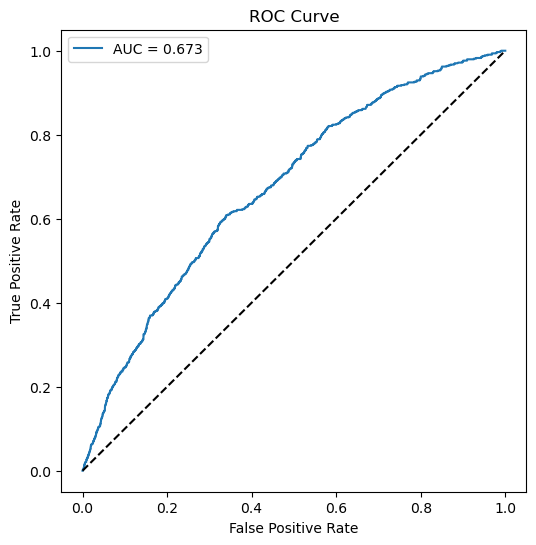

In [49]:
# Get predicted probabilities for the positive class# y_scores = probability of TARGET = 1
y_scores = lr.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

print("AUC:", auc)


# Plot ROC Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  # diagonal for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()